# RLHF for NMT with Prompt Optimization (Fixed)

**Extended Algorithm with Prompt Model**

Components:
- **Reward Model**: Multi-head (Qualitative + Quantitative)
- **Prompt Model**: Generates optimized prompts (policy gradient)
- **Translation Model**: GRPO optimization

**Requires GPU Runtime**

In [1]:
!pip install -q transformers>=4.36.0 accelerate datasets
!pip install -q trl==0.27.0 peft>=0.6.0 bitsandbytes
!pip install -q sacrebleu sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.1 MB/s eta 0:00:00


In [2]:
pip install --upgrade accelerate torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 89.2 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from dataclasses import dataclass
from typing import List, Dict, Tuple
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from trl import AutoModelForCausalLMWithValueHead
import sacrebleu

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [4]:
@dataclass
class Config:
    base_model_name: str = 'Qwen/Qwen2.5-7B-Instruct'
    reward_model_name: str = 'Qwen/Qwen2.5-7B-Instruct'
    prompt_model_name: str = 'Qwen/Qwen2.5-7B-Instruct'
    num_iterations: int = 2
    rm_training_steps: int = 30
    prompt_training_steps: int = 15
    llm_training_steps: int = 15
    learning_rate_rm: float = 1e-5
    learning_rate_llm: float = 1e-5
    learning_rate_prompt: float = 5e-6
    epsilon: float = 0.2
    beta: float = 0.01
    num_samples_per_prompt: int = 4
    num_prompt_samples: int = 2
    prompt_max_length: int = 60
    prompt_temperature: float = 0.8
    alpha: float = 1.0
    similarity_threshold: float = 0.8
    lora_r: int = 8
    lora_alpha: int = 16
    lora_dropout: float = 0.05
    max_length: int = 256
    seed: int = 42

config = Config()
print('Config loaded!')

Config loaded!


In [5]:
def compute_bleu(ref, hyp):
    try:
        return sacrebleu.sentence_bleu(hyp, [ref]).score / 100.0
    except:
        return 0.0

class RMDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=256):
        self.data, self.tokenizer, self.max_length = data, tokenizer, max_length
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        item = self.data[idx]
        prefix = f"Prompt: {item.get('prompt', '')}\n" if item.get('prompt') else ''
        chosen = f"{prefix}Source: {item['source']}\nTranslation: {item['strong_translation']}"
        rejected = f"{prefix}Source: {item['source']}\nTranslation: {item['weak_translation']}"
        c = self.tokenizer(chosen, max_length=self.max_length, padding='max_length', truncation=True, return_tensors='pt')
        r = self.tokenizer(rejected, max_length=self.max_length, padding='max_length', truncation=True, return_tensors='pt')
        return {'chosen_input_ids': c['input_ids'].squeeze(), 'chosen_attention_mask': c['attention_mask'].squeeze(),
                'rejected_input_ids': r['input_ids'].squeeze(), 'rejected_attention_mask': r['attention_mask'].squeeze(),
                'strong_bleu': torch.tensor(item.get('strong_bleu', 1.0)), 'weak_bleu': torch.tensor(item.get('weak_bleu', 0.0))}

print('Utilities loaded!')

Utilities loaded!


In [6]:
class MultiHeadRewardModel(nn.Module):
    def __init__(self, model_name, config):
        super().__init__()
        self.config = config
        bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type='nf4', bnb_4bit_compute_dtype=torch.float16)
        self.base_model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=bnb, device_map='auto', trust_remote_code=True)
        self.base_model = prepare_model_for_kbit_training(self.base_model)
        h = self.base_model.config.hidden_size
        self.qual_head = nn.Linear(h, 1).to(device)
        self.quant_head = nn.Linear(h, 1).to(device)

    def forward(self, input_ids, attention_mask):
        out = self.base_model(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)
        h = out.hidden_states[-1]
        seq_lens = attention_mask.sum(dim=1) - 1
        pooled = h[torch.arange(input_ids.shape[0], device=device), seq_lens]
        return self.qual_head(pooled).squeeze(-1), torch.sigmoid(self.quant_head(pooled)).squeeze(-1)

    def get_reward(self, input_ids, attention_mask):
        q, qu = self.forward(input_ids, attention_mask)
        return q + self.config.alpha * qu

print('MultiHeadRewardModel defined!')

MultiHeadRewardModel defined!


In [7]:
class PromptModel(nn.Module):
    """
    Prompt Model that learns to generate optimized translation instructions.
    Uses REINFORCE with baseline for policy gradient training.
    """
    def __init__(self, model_name, tokenizer, config):
        super().__init__()
        self.config, self.tokenizer = config, tokenizer

        # Load model WITHOUT gradient checkpointing for proper backprop
        self.model = AutoModelForCausalLM.from_pretrained(
            model_name,
            device_map='auto',
            trust_remote_code=True,
            torch_dtype=torch.float16
        )

        # Apply LoRA
        lora = LoraConfig(
            r=config.lora_r,
            lora_alpha=config.lora_alpha,
            lora_dropout=config.lora_dropout,
            target_modules=['q_proj', 'v_proj'],
            task_type=TaskType.CAUSAL_LM
        )
        self.model = get_peft_model(self.model, lora)

        # Disable gradient checkpointing to allow proper gradient flow
        self.model.config.use_cache = True
        if hasattr(self.model, 'gradient_checkpointing_disable'):
            self.model.gradient_checkpointing_disable()

        # Meta-prompt template
        self.meta = """Generate a short instruction for translating this Ijor text to Russian.

Text: {source}

Instruction:"""

    def generate_prompts(self, sources, num_samples=2):
        """Generate prompt variations (no gradients needed here)"""
        all_prompts = []
        self.model.eval()
        with torch.no_grad():
            for src in sources:
                prompts = []
                meta = self.meta.format(source=src)
                inp = self.tokenizer(meta, return_tensors='pt', max_length=self.config.max_length, truncation=True).to(device)
                for i in range(num_samples):
                    out = self.model.generate(
                        **inp,
                        max_new_tokens=self.config.prompt_max_length,
                        do_sample=True,
                        temperature=self.config.prompt_temperature + i*0.15,
                        top_p=0.9,
                        pad_token_id=self.tokenizer.pad_token_id
                    )
                    gen = self.tokenizer.decode(out[0][inp['input_ids'].shape[1]:], skip_special_tokens=True).strip()
                    # Clean up
                    if '.' in gen:
                        gen = gen[:gen.rfind('.')+1]
                    gen = ' '.join(gen.split()[:30])  # Limit length
                    if not gen:
                        gen = 'Translate naturally to Russian.'
                    prompts.append(gen)
                all_prompts.append(prompts)
        return all_prompts

    def compute_log_probs(self, source, prompt):
        """
        Compute log probabilities WITH gradients for policy gradient.
        This is the key fix - we need gradients to flow through.
        """
        self.model.train()  # Enable training mode

        meta = self.meta.format(source=source)
        full_text = meta + prompt

        # Tokenize
        full_inp = self.tokenizer(
            full_text,
            return_tensors='pt',
            max_length=self.config.max_length * 2,
            truncation=True
        ).to(device)

        meta_inp = self.tokenizer(
            meta,
            return_tensors='pt',
            max_length=self.config.max_length,
            truncation=True
        ).to(device)

        prompt_start = meta_inp['input_ids'].shape[1]

        # Forward pass WITH gradients
        outputs = self.model(
            input_ids=full_inp['input_ids'],
            attention_mask=full_inp['attention_mask'],
            use_cache=False  # Disable cache for gradient computation
        )
        logits = outputs.logits

        # Get log probs for generated tokens only
        # Shift: predict token t from position t-1
        shift_logits = logits[:, prompt_start-1:-1, :]
        shift_labels = full_inp['input_ids'][:, prompt_start:]

        # Compute log probabilities
        log_probs = F.log_softmax(shift_logits, dim=-1)

        # Gather log probs for actual tokens
        token_log_probs = log_probs.gather(-1, shift_labels.unsqueeze(-1)).squeeze(-1)

        # Sum log probs (or mean for stability)
        return token_log_probs.sum()


print('PromptModel defined!')

PromptModel defined!


In [8]:
class PromptTrainer:
    """
    Trainer for Prompt Model using REINFORCE algorithm.

    The prompt model learns to generate instructions that maximize
    translation quality as measured by the reward model.

    Loss = -log_prob(prompt) * advantage
    where advantage = (reward - baseline) / std
    """

    def __init__(self, pm, rm, tm, tok, cfg):
        self.pm, self.rm, self.tm, self.tok, self.cfg = pm, rm, tm, tok, cfg

        # Optimizer for LoRA parameters only
        trainable_params = [p for p in pm.model.parameters() if p.requires_grad]
        self.opt = torch.optim.AdamW(trainable_params, lr=cfg.learning_rate_prompt)

        # Moving average baseline for variance reduction
        self.baseline = 0.0
        self.baseline_decay = 0.9

    def get_reward(self, src, prompt, trans):
        """Get reward from reward model (no gradients needed)"""
        inp = f'Prompt: {prompt}\nSource: {src}\nTranslation: {trans}'
        tok = self.tok(inp, return_tensors='pt', max_length=self.cfg.max_length, truncation=True, padding=True).to(device)
        with torch.no_grad():
            return self.rm.get_reward(tok['input_ids'], tok['attention_mask']).item()

    def train_step(self, sources):
        """Single training step using REINFORCE"""

        all_rewards = []
        all_log_probs = []

        for src in sources:
            # Step 1: Generate prompts (no grad)
            prompts = self.pm.generate_prompts([src], self.cfg.num_prompt_samples)[0]

            for prompt in prompts:
                # Step 2: Generate translation using this prompt (no grad)
                full_prompt = f'{prompt}\n\nSource: {src}\n\nTranslation:'
                with torch.no_grad():
                    trans = self.tm.generate_samples([full_prompt], 1)[0][0]

                # Step 3: Get reward (no grad)
                reward = self.get_reward(src, prompt, trans)
                all_rewards.append(reward)

                # Step 4: Compute log prob WITH gradients
                log_prob = self.pm.compute_log_probs(src, prompt)
                all_log_probs.append(log_prob)

        if len(all_rewards) == 0:
            return {'reward': 0.0, 'baseline': self.baseline, 'loss': 0.0}

        # Convert rewards to tensor
        rewards = torch.tensor(all_rewards, device=device, dtype=torch.float32)

        # Update baseline (moving average)
        mean_reward = rewards.mean().item()
        self.baseline = self.baseline_decay * self.baseline + (1 - self.baseline_decay) * mean_reward

        # Compute advantages
        advantages = (rewards - self.baseline) / (rewards.std() + 1e-8)

        # Compute policy gradient loss: -log_prob * advantage
        # We want to maximize reward, so minimize negative
        loss = torch.tensor(0.0, device=device, requires_grad=True)
        for log_prob, adv in zip(all_log_probs, advantages):
            # Detach advantage (it's just a scalar weight)
            loss = loss + (-log_prob * adv.detach())

        loss = loss / len(all_log_probs)

        # Backprop and update
        self.opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.pm.model.parameters(), 1.0)
        self.opt.step()

        return {
            'reward': mean_reward,
            'baseline': self.baseline,
            'loss': loss.item()
        }

    def train(self, sources, steps):
        """Train for specified number of steps"""
        metrics = []
        batch_size = 2  # Small batch for memory

        for s in range(steps):
            # Sample batch of sources
            idx = np.random.choice(len(sources), min(batch_size, len(sources)), replace=False)
            batch = [sources[i] for i in idx]

            m = self.train_step(batch)
            m['step'] = s
            metrics.append(m)

            if s % 5 == 0:
                print(f'    Prompt Step {s}: R={m["reward"]:.4f}, Loss={m["loss"]:.4f}')

        return metrics


print('PromptTrainer defined!')

PromptTrainer defined!


In [9]:
class RMTrainer:
    def __init__(self, model, tok, cfg):
        self.model, self.tok, self.cfg = model, tok, cfg
        self.opt = torch.optim.AdamW(
            list(model.qual_head.parameters()) + list(model.quant_head.parameters()),
            lr=cfg.learning_rate_rm
        )

    def train(self, loader, steps):
        metrics, step = [], 0
        while step < steps:
            for batch in loader:
                if step >= steps: break
                self.model.train()
                self.opt.zero_grad()

                cq, cqu = self.model(batch['chosen_input_ids'].to(device), batch['chosen_attention_mask'].to(device))
                rq, rqu = self.model(batch['rejected_input_ids'].to(device), batch['rejected_attention_mask'].to(device))

                diff = cq - rq
                L_rank = -F.logsigmoid(diff).mean()
                L_mae = (torch.abs(cqu - batch['strong_bleu'].to(device).float()).mean() +
                         torch.abs(rqu - batch['weak_bleu'].to(device).float()).mean()) / 2
                loss = L_rank + self.cfg.alpha * L_mae

                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    list(self.model.qual_head.parameters()) + list(self.model.quant_head.parameters()),
                    1.0
                )
                self.opt.step()

                metrics.append({'loss': loss.item(), 'acc': (diff > 0).float().mean().item()})
                if step % 10 == 0:
                    print(f'  RM Step {step}: Loss={loss.item():.4f}, Acc={metrics[-1]["acc"]:.4f}')
                step += 1
        return metrics


print('RMTrainer defined!')

RMTrainer defined!


In [10]:
class TranslationModel:
    def __init__(self, name, tok, cfg):
        self.cfg, self.tok = cfg, tok
        lora = LoraConfig(
            r=cfg.lora_r,
            lora_alpha=cfg.lora_alpha,
            lora_dropout=cfg.lora_dropout,
            target_modules=['q_proj', 'v_proj'],
            task_type=TaskType.CAUSAL_LM
        )
        self.model = AutoModelForCausalLMWithValueHead.from_pretrained(
            name,
            peft_config=lora,
            device_map='auto',
            trust_remote_code=True,
            torch_dtype=torch.float16
        )

    def generate_samples(self, prompts, n=4):
        all_s = []
        self.model.eval()
        with torch.no_grad():
            for p in prompts:
                samples = []
                inp = self.tok(p, return_tensors='pt', max_length=self.cfg.max_length, truncation=True).to(device)
                for _ in range(n):
                    out = self.model.generate(
                        **inp,
                        max_new_tokens=80,
                        do_sample=True,
                        temperature=0.7,
                        top_p=0.9,
                        pad_token_id=self.tok.pad_token_id
                    )
                    samples.append(self.tok.decode(out[0][inp['input_ids'].shape[1]:], skip_special_tokens=True))
                all_s.append(samples)
        return all_s


print('TranslationModel defined!')

TranslationModel defined!


In [11]:
class MainTrainer:
    """
    Main trainer implementing extended Algorithm 1 with Prompt Model.

    Training Loop:
    for k = 1..N:
        1. Filter data by similarity
        2. Train Reward Model (ranking + BLEU prediction)
        3. Train Prompt Model (policy gradient)
        4. Select best prompts for each source
        5. Train Translation Model with optimized prompts
    """

    def __init__(self, cfg):
        self.cfg = cfg

        print('Loading tokenizer...')
        self.tok = AutoTokenizer.from_pretrained(cfg.base_model_name, trust_remote_code=True)
        if self.tok.pad_token is None:
            self.tok.pad_token = self.tok.eos_token

        print('Loading RM...')
        self.rm = MultiHeadRewardModel(cfg.reward_model_name, cfg)

        print('Loading TM...')
        self.tm = TranslationModel(cfg.base_model_name, self.tok, cfg)

        print('Loading PM...')
        self.pm = PromptModel(cfg.prompt_model_name, self.tok, cfg)

        # Initialize trainers
        self.rm_tr = RMTrainer(self.rm, self.tok, cfg)
        self.pm_tr = PromptTrainer(self.pm, self.rm, self.tm, self.tok, cfg)

        # Store best prompts per source
        self.best_prompts = {}

    def select_best_prompts(self, sources):
        """Select best prompt for each source based on reward"""
        print('  Selecting best prompts...')

        for src in sources:
            prompts = self.pm.generate_prompts([src], num_samples=3)[0]

            best_prompt, best_reward = 'Translate Ijor to Russian.', float('-inf')

            for p in prompts:
                # Generate translation with this prompt
                full = f'{p}\n\nSource: {src}\n\nTranslation:'
                with torch.no_grad():
                    trans = self.tm.generate_samples([full], 1)[0][0]

                # Score it
                inp = f'Prompt: {p}\nSource: {src}\nTranslation: {trans}'
                tok = self.tok(inp, return_tensors='pt', max_length=self.cfg.max_length,
                               truncation=True, padding=True).to(device)
                with torch.no_grad():
                    r = self.rm.get_reward(tok['input_ids'], tok['attention_mask']).item()

                if r > best_reward:
                    best_reward, best_prompt = r, p

            self.best_prompts[src] = best_prompt

    def train(self, D_RM, D_LLM):
        all_rm, all_pm, all_llm = [], [], []
        sources = list(set([x['source'] for x in D_RM + D_LLM]))

        for k in range(1, self.cfg.num_iterations + 1):
            print(f'\n{"="*50}')
            print(f'Iteration {k}/{self.cfg.num_iterations}')
            print(f'{"="*50}')

            # Step 1: Filter data
            D_star = []
            for x in D_RM:
                bleu = compute_bleu(x['strong_translation'], x['weak_translation'])
                if bleu < self.cfg.similarity_threshold:
                    D_star.append({
                        'source': x['source'],
                        'strong_translation': x['strong_translation'],
                        'weak_translation': x['weak_translation'],
                        'strong_bleu': 1.0,
                        'weak_bleu': bleu,
                        'prompt': self.best_prompts.get(x['source'], '')
                    })
            print(f'\nFiltered: {len(D_star)} samples')

            if not D_star:
                continue

            # Step 2: Train RM
            print('\n--- RM Training ---')
            loader = DataLoader(RMDataset(D_star, self.tok, self.cfg.max_length), batch_size=2, shuffle=True)
            all_rm.extend(self.rm_tr.train(loader, self.cfg.rm_training_steps))

            # Step 3: Train Prompt Model
            print('\n--- Prompt Model Training ---')
            pm_metrics = self.pm_tr.train(sources[:10], self.cfg.prompt_training_steps)
            all_pm.extend(pm_metrics)

            # Step 4: Select best prompts
            self.select_best_prompts(sources[:8])

            # Step 5: Train LLM with optimized prompts
            print('\n--- LLM Training (with optimized prompts) ---')
            for i, item in enumerate(D_LLM[:self.cfg.llm_training_steps]):
                src = item['source']
                instr = self.best_prompts.get(src, 'Translate Ijor to Russian.')

                # Generate translations with optimized prompt
                samples = self.tm.generate_samples(
                    [f'{instr}\n\nSource: {src}\n\nTranslation:'],
                    self.cfg.num_samples_per_prompt
                )[0]

                # Score them
                rewards = []
                for s in samples:
                    inp = f'Prompt: {instr}\nSource: {src}\nTranslation: {s}'
                    tok = self.tok(inp, return_tensors='pt', max_length=self.cfg.max_length,
                                   truncation=True, padding=True).to(device)
                    with torch.no_grad():
                        rewards.append(self.rm.get_reward(tok['input_ids'], tok['attention_mask']).item())

                all_llm.append({'step': i, 'reward': np.mean(rewards)})

                if i % 5 == 0:
                    print(f'  LLM Step {i}: Reward={np.mean(rewards):.4f}')

            print(f'\nIteration {k} complete!')

        print(f'\n{"="*50}')
        print('Training Complete!')
        print(f'{"="*50}')

        return {
            'rm': all_rm,
            'prompt': all_pm,
            'llm': all_llm,
            'best_prompts': self.best_prompts
        }


print('MainTrainer defined!')

MainTrainer defined!


In [12]:
# Sample training data
# samples = [
#     {'source': 'Hey, what\'s up? Long time no see!',
#      'strong_translation': '嘿，最近怎么样？好久不见！',
#      'weak_translation': '嘿，什么事？长时间没见！'},
#     {'source': 'I\'m totally gonna crush this exam tomorrow.',
#      'strong_translation': '明天的考试我肯定能搞定。',
#      'weak_translation': '我完全要粉碎明天的考试。'},
#     {'source': 'That movie was absolutely mind-blowing!',
#      'strong_translation': '那部电影太震撼了！',
#      'weak_translation': '那个电影绝对是让人头脑爆炸的！'},
#     {'source': 'Can you give me a hand with this?',
#      'strong_translation': '能帮我一下吗？',
#      'weak_translation': '你能给我一只手吗？'},
#     {'source': 'Let\'s grab a bite to eat.',
#      'strong_translation': '我们去吃点东西吧。',
#      'weak_translation': '让我们抓一口吃的。'},
#     {'source': 'That\'s sick! I love it!',
#      'strong_translation': '太酷了！我超喜欢！',
#      'weak_translation': '那是生病的！我爱它！'},
#     {'source': 'I\'ve been swamped with work lately.',
#      'strong_translation': '最近工作忙得不可开交。',
#      'weak_translation': '我最近被工作淹没了。'},
#     {'source': 'This place is lit!',
#      'strong_translation': '这地方太火了！',
#      'weak_translation': '这个地方被点燃了！'},
# ]
from samples_cleaned import *

# Extend data
extended = [{**samples[i % len(samples)], 'id': i} for i in range(40)]
D_RM, D_LLM = extended[:20], extended[20:]
print(f'Data: {len(D_RM)} RM samples, {len(D_LLM)} LLM samples')

Data: 20 RM samples, 20 LLM samples


---
## Experiments with Different Step Counts

The following cells run experiments with different training step configurations:
- **50 steps**: Quick experiment
- **75 steps**: Medium experiment
- **100 steps**: Full experiment

All metrics and graphics will be saved to `/content/rlhf_experiments/`

In [13]:
import os
import json
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd

# Create experiment directory
EXPERIMENT_DIR = '/content/rlhf_experiments'
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

def get_experiment_dir(experiment_name):
    """Create and return experiment-specific directory"""
    exp_dir = os.path.join(EXPERIMENT_DIR, experiment_name)
    os.makedirs(exp_dir, exist_ok=True)
    return exp_dir

def save_metrics_json(metrics, filepath):
    """Save metrics to JSON file"""
    with open(filepath, 'w') as f:
        json.dump(metrics, f, indent=2, default=str)
    print(f'Saved metrics to: {filepath}')

def save_metrics_csv(metrics_dict, filepath):
    """Save metrics to CSV file"""
    # Flatten metrics for CSV
    rows = []
    for component, metrics in metrics_dict.items():
        if component == 'best_prompts':
            continue
        for i, m in enumerate(metrics):
            row = {'component': component, 'step': i}
            row.update(m)
            rows.append(row)
    df = pd.DataFrame(rows)
    df.to_csv(filepath, index=False)
    print(f'Saved CSV to: {filepath}')

print('Experiment utilities loaded!')

Experiment utilities loaded!


In [14]:
def plot_and_save_all_metrics(results, save_dir, experiment_name, config_info):
    """
    Generate and save all metrics plots for an experiment.

    Creates:
    1. Individual component plots (RM, Prompt, LLM)
    2. Combined overview plot
    3. Detailed reward progression plots
    4. Summary statistics
    """

    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

    # ==================== 1. Reward Model Plots ====================
    if results['rm']:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Loss curve
        rm_losses = [m['loss'] for m in results['rm']]
        axes[0].plot(rm_losses, 'b-', linewidth=2)
        axes[0].fill_between(range(len(rm_losses)), rm_losses, alpha=0.3)
        axes[0].set_title(f'Reward Model Loss\n{experiment_name}', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Training Step')
        axes[0].set_ylabel('Loss')
        axes[0].grid(True, alpha=0.3)

        # Accuracy curve
        rm_accs = [m['acc'] for m in results['rm']]
        axes[1].plot(rm_accs, 'g-', linewidth=2)
        axes[1].fill_between(range(len(rm_accs)), rm_accs, alpha=0.3, color='green')
        axes[1].set_title(f'Reward Model Accuracy\n{experiment_name}', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Training Step')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_ylim(0, 1.05)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        rm_path = os.path.join(save_dir, f'rm_metrics_{timestamp}.png')
        plt.savefig(rm_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved RM plot: {rm_path}')

    # ==================== 2. Prompt Model Plots ====================
    if results['prompt']:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Reward curve
        pm_rewards = [m['reward'] for m in results['prompt']]
        pm_baselines = [m['baseline'] for m in results['prompt']]
        axes[0].plot(pm_rewards, 'b-', linewidth=2, label='Reward', marker='o', markersize=4)
        axes[0].plot(pm_baselines, 'r--', linewidth=2, label='Baseline', alpha=0.7)
        axes[0].fill_between(range(len(pm_rewards)), pm_rewards, pm_baselines, alpha=0.2)
        axes[0].set_title(f'Prompt Model Reward vs Baseline\n{experiment_name}', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Training Step')
        axes[0].set_ylabel('Reward')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Loss curve
        pm_losses = [m['loss'] for m in results['prompt']]
        axes[1].plot(pm_losses, 'm-', linewidth=2)
        axes[1].set_title(f'Prompt Model Loss\n{experiment_name}', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Training Step')
        axes[1].set_ylabel('Loss')
        axes[1].grid(True, alpha=0.3)

        # Advantage (reward - baseline)
        advantages = [r - b for r, b in zip(pm_rewards, pm_baselines)]
        colors = ['green' if a > 0 else 'red' for a in advantages]
        axes[2].bar(range(len(advantages)), advantages, color=colors, alpha=0.7)
        axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        axes[2].set_title(f'Prompt Model Advantage\n{experiment_name}', fontsize=12, fontweight='bold')
        axes[2].set_xlabel('Training Step')
        axes[2].set_ylabel('Advantage (R - Baseline)')
        axes[2].grid(True, alpha=0.3)

        plt.tight_layout()
        pm_path = os.path.join(save_dir, f'prompt_model_metrics_{timestamp}.png')
        plt.savefig(pm_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved Prompt Model plot: {pm_path}')

    # ==================== 3. LLM Reward Plots ====================
    if results['llm']:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        llm_rewards = [m['reward'] for m in results['llm']]

        # Raw rewards
        axes[0].plot(llm_rewards, 'c-', linewidth=2, marker='s', markersize=4)
        axes[0].fill_between(range(len(llm_rewards)), llm_rewards, alpha=0.3, color='cyan')
        axes[0].set_title(f'LLM Reward (with Optimized Prompts)\n{experiment_name}', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Training Step')
        axes[0].set_ylabel('Reward')
        axes[0].grid(True, alpha=0.3)

        # Moving average
        window = min(5, len(llm_rewards))
        if len(llm_rewards) >= window:
            moving_avg = pd.Series(llm_rewards).rolling(window=window, min_periods=1).mean()
            axes[1].plot(llm_rewards, 'c-', alpha=0.4, label='Raw')
            axes[1].plot(moving_avg, 'b-', linewidth=3, label=f'Moving Avg (w={window})')
            axes[1].set_title(f'LLM Reward with Moving Average\n{experiment_name}', fontsize=12, fontweight='bold')
            axes[1].set_xlabel('Training Step')
            axes[1].set_ylabel('Reward')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        llm_path = os.path.join(save_dir, f'llm_metrics_{timestamp}.png')
        plt.savefig(llm_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved LLM plot: {llm_path}')

    # ==================== 4. Combined Overview Plot ====================
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'RLHF Training Overview - {experiment_name}\n{config_info}', fontsize=14, fontweight='bold')

    # RM Loss
    if results['rm']:
        axes[0, 0].plot([m['loss'] for m in results['rm']], 'b-', linewidth=2)
        axes[0, 0].set_title('Reward Model Loss', fontsize=11)
        axes[0, 0].set_xlabel('Step')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].grid(True, alpha=0.3)

    # RM Accuracy
    if results['rm']:
        axes[0, 1].plot([m['acc'] for m in results['rm']], 'g-', linewidth=2)
        axes[0, 1].set_title('Reward Model Accuracy', fontsize=11)
        axes[0, 1].set_xlabel('Step')
        axes[0, 1].set_ylabel('Accuracy')
        axes[0, 1].set_ylim(0, 1.05)
        axes[0, 1].grid(True, alpha=0.3)

    # Prompt Model Reward
    if results['prompt']:
        axes[1, 0].plot([m['reward'] for m in results['prompt']], 'b-', label='Reward', linewidth=2)
        axes[1, 0].plot([m['baseline'] for m in results['prompt']], 'r--', label='Baseline', linewidth=2)
        axes[1, 0].set_title('Prompt Model Training', fontsize=11)
        axes[1, 0].set_xlabel('Step')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)

    # LLM Reward
    if results['llm']:
        axes[1, 1].plot([m['reward'] for m in results['llm']], 'c-', linewidth=2)
        axes[1, 1].set_title('LLM Reward (with Optimized Prompts)', fontsize=11)
        axes[1, 1].set_xlabel('Step')
        axes[1, 1].set_ylabel('Reward')
        axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    overview_path = os.path.join(save_dir, f'overview_{timestamp}.png')
    plt.savefig(overview_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved overview plot: {overview_path}')

    # ==================== 5. Summary Statistics ====================
    summary = {
        'experiment_name': experiment_name,
        'timestamp': timestamp,
        'config': config_info
    }

    if results['rm']:
        rm_losses = [m['loss'] for m in results['rm']]
        rm_accs = [m['acc'] for m in results['rm']]
        summary['rm'] = {
            'total_steps': len(results['rm']),
            'final_loss': rm_losses[-1],
            'min_loss': min(rm_losses),
            'avg_loss': np.mean(rm_losses),
            'final_acc': rm_accs[-1],
            'max_acc': max(rm_accs),
            'avg_acc': np.mean(rm_accs)
        }

    if results['prompt']:
        pm_rewards = [m['reward'] for m in results['prompt']]
        pm_losses = [m['loss'] for m in results['prompt']]
        summary['prompt_model'] = {
            'total_steps': len(results['prompt']),
            'final_reward': pm_rewards[-1],
            'max_reward': max(pm_rewards),
            'avg_reward': np.mean(pm_rewards),
            'final_loss': pm_losses[-1],
            'reward_improvement': pm_rewards[-1] - pm_rewards[0] if len(pm_rewards) > 1 else 0
        }

    if results['llm']:
        llm_rewards = [m['reward'] for m in results['llm']]
        summary['llm'] = {
            'total_steps': len(results['llm']),
            'final_reward': llm_rewards[-1],
            'max_reward': max(llm_rewards),
            'avg_reward': np.mean(llm_rewards),
            'reward_improvement': llm_rewards[-1] - llm_rewards[0] if len(llm_rewards) > 1 else 0
        }

    summary['best_prompts_count'] = len(results.get('best_prompts', {}))

    # Save summary
    summary_path = os.path.join(save_dir, f'summary_{timestamp}.json')
    with open(summary_path, 'w') as f:
        json.dump(summary, f, indent=2, default=float)
    print(f'Saved summary: {summary_path}')

    # Print summary
    print('\n' + '='*60)
    print(f'EXPERIMENT SUMMARY: {experiment_name}')
    print('='*60)
    for key, value in summary.items():
        if isinstance(value, dict):
            print(f'\n{key.upper()}:')
            for k, v in value.items():
                print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')
        else:
            print(f'{key}: {value}')

    return summary

print('Plotting utilities loaded!')

Plotting utilities loaded!


In [15]:
def run_experiment(step_config, experiment_name, D_RM, D_LLM):
    """
    Run a complete experiment with specified step configuration.

    Args:
        step_config: dict with rm_steps, prompt_steps, llm_steps
        experiment_name: name for this experiment
        D_RM, D_LLM: training data

    Returns:
        results: training results
        summary: summary statistics
    """
    print('\n' + '='*70)
    print(f'STARTING EXPERIMENT: {experiment_name}')
    print(f'Configuration: {step_config}')
    print('='*70 + '\n')

    # Create config with custom steps
    exp_config = Config()
    exp_config.rm_training_steps = step_config['rm_steps']
    exp_config.prompt_training_steps = step_config['prompt_steps']
    exp_config.llm_training_steps = step_config['llm_steps']
    exp_config.num_iterations = step_config.get('iterations', 2)

    # Set seeds for reproducibility
    torch.manual_seed(42)
    np.random.seed(42)

    # Create trainer and run
    trainer = MainTrainer(exp_config)
    results = trainer.train(D_RM, D_LLM)

    # Create experiment directory and save results
    exp_dir = get_experiment_dir(experiment_name)

    # Config info string
    config_info = f"RM:{step_config['rm_steps']} | PM:{step_config['prompt_steps']} | LLM:{step_config['llm_steps']} | Iter:{exp_config.num_iterations}"

    # Save all plots and metrics
    summary = plot_and_save_all_metrics(results, exp_dir, experiment_name, config_info)

    # Save raw metrics
    metrics_path = os.path.join(exp_dir, 'raw_metrics.json')
    save_metrics_json({
        'rm': results['rm'],
        'prompt': results['prompt'],
        'llm': results['llm'],
        'best_prompts': results['best_prompts']
    }, metrics_path)

    # Save as CSV for easy analysis
    csv_path = os.path.join(exp_dir, 'metrics.csv')
    save_metrics_csv(results, csv_path)

    # Save best prompts separately
    prompts_path = os.path.join(exp_dir, 'best_prompts.json')
    save_metrics_json(results['best_prompts'], prompts_path)

    # Store trainer for later use
    results['trainer'] = trainer
    results['config'] = step_config
    results['summary'] = summary

    print(f'\nExperiment {experiment_name} complete!')
    print(f'All files saved to: {exp_dir}')

    return results

print('Experiment runner loaded!')

Experiment runner loaded!


### Experiment 1: 50 Total Steps (Quick)

In [ ]:
# Experiment 1: 50 total steps
# config_50 = {
#     'rm_steps': 20,
#     'prompt_steps': 15,
#     'llm_steps': 15,
#     'iterations': 10
# }

# results_50 = run_experiment(config_50, 'experiment_50_steps', D_RM, D_LLM)

In [ ]:
# import IPython
# IPython.Application.instance().kernel.do_shutdown(restart=True)

### Experiment 2: 75 Total Steps (Medium)


STARTING EXPERIMENT: experiment_75_steps
Configuration: {'rm_steps': 30, 'prompt_steps': 22, 'llm_steps': 23, 'iterations': 10}

Loading tokenizer...


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading PM...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]


Iteration 1/10

Filtered: 20 samples

--- RM Training ---


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


  RM Step 0: Loss=1.1199, Acc=0.5000
  RM Step 10: Loss=0.5177, Acc=1.0000
  RM Step 20: Loss=0.3912, Acc=1.0000

--- Prompt Model Training ---
    Prompt Step 0: R=0.4129, Loss=2.2324
    Prompt Step 5: R=0.0932, Loss=4.9875
    Prompt Step 10: R=-1.3783, Loss=-1.6358
    Prompt Step 15: R=-0.4323, Loss=9.6146
    Prompt Step 20: R=-0.2729, Loss=7.6397
  Selecting best prompts...

--- LLM Training (with optimized prompts) ---
  LLM Step 0: Reward=1.1822
  LLM Step 5: Reward=-0.4770
  LLM Step 10: Reward=0.8000
  LLM Step 15: Reward=-0.6836

Iteration 1 complete!

Iteration 2/10

Filtered: 20 samples

--- RM Training ---
  RM Step 0: Loss=1.3515, Acc=0.5000
  RM Step 10: Loss=0.5747, Acc=1.0000
  RM Step 20: Loss=0.5578, Acc=1.0000

--- Prompt Model Training ---
    Prompt Step 0: R=-2.2069, Loss=-6.9409
    Prompt Step 5: R=-2.3624, Loss=-28.6768
    Prompt Step 10: R=-2.1711, Loss=-38.4570
    Prompt Step 15: R=1.4080, Loss=37.3690
    Prompt Step 20: R=-0.4005, Loss=5.6502
  Selecti

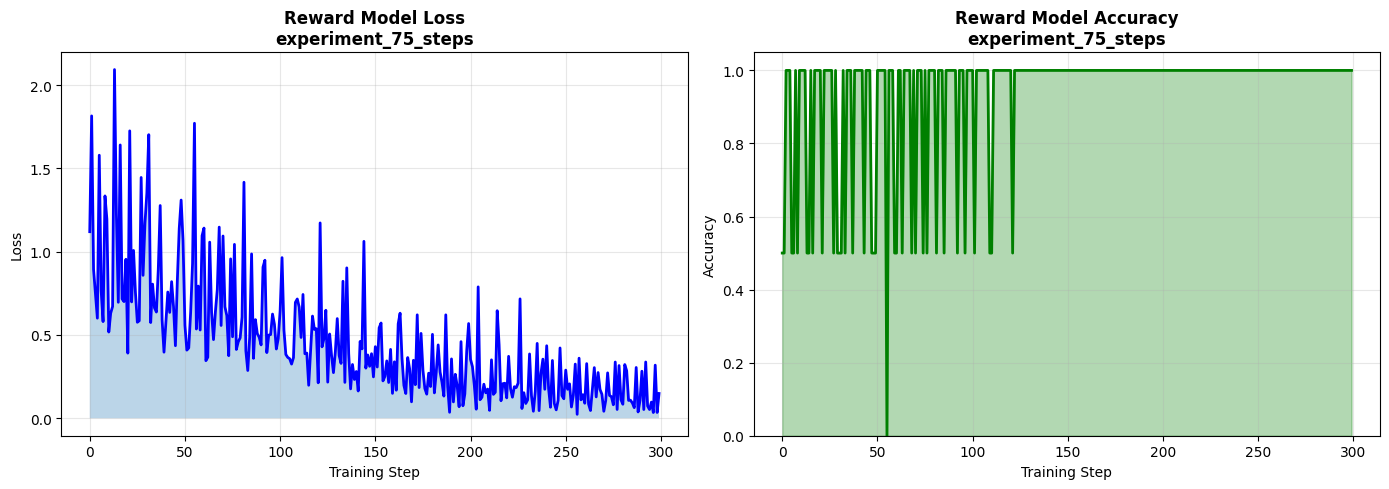

Saved RM plot: /content/rlhf_experiments/experiment_75_steps/rm_metrics_20260428_140343.png


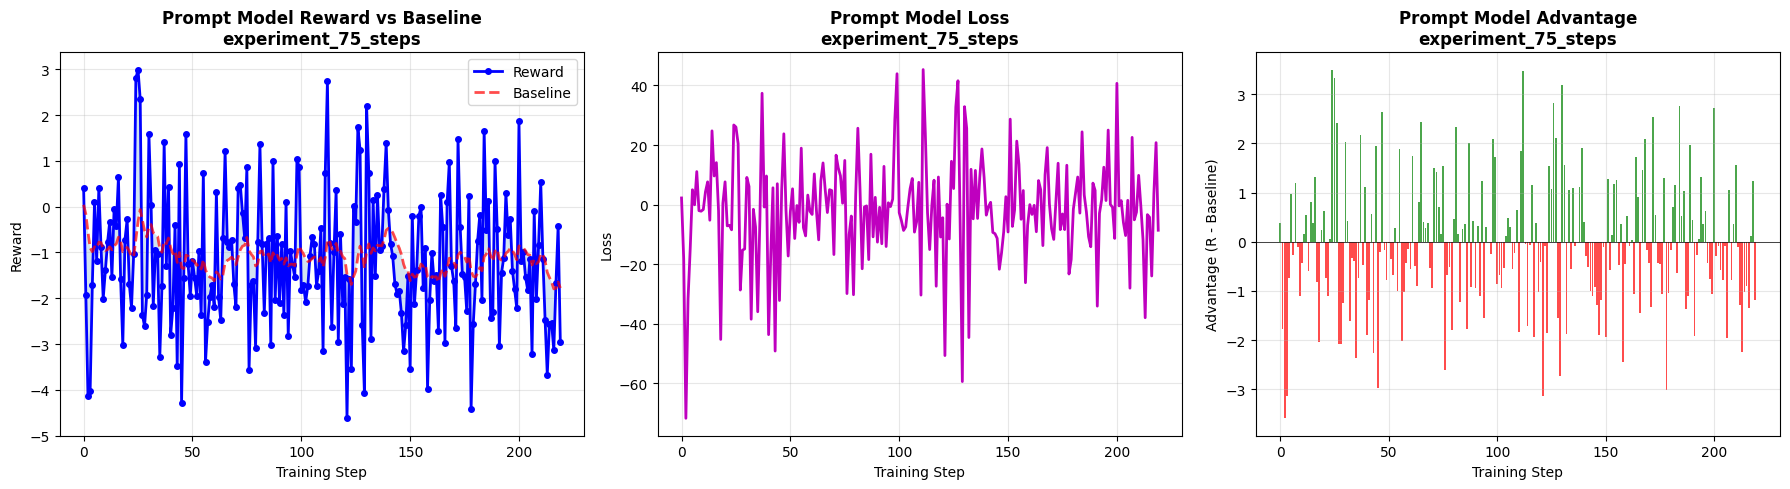

Saved Prompt Model plot: /content/rlhf_experiments/experiment_75_steps/prompt_model_metrics_20260428_140343.png


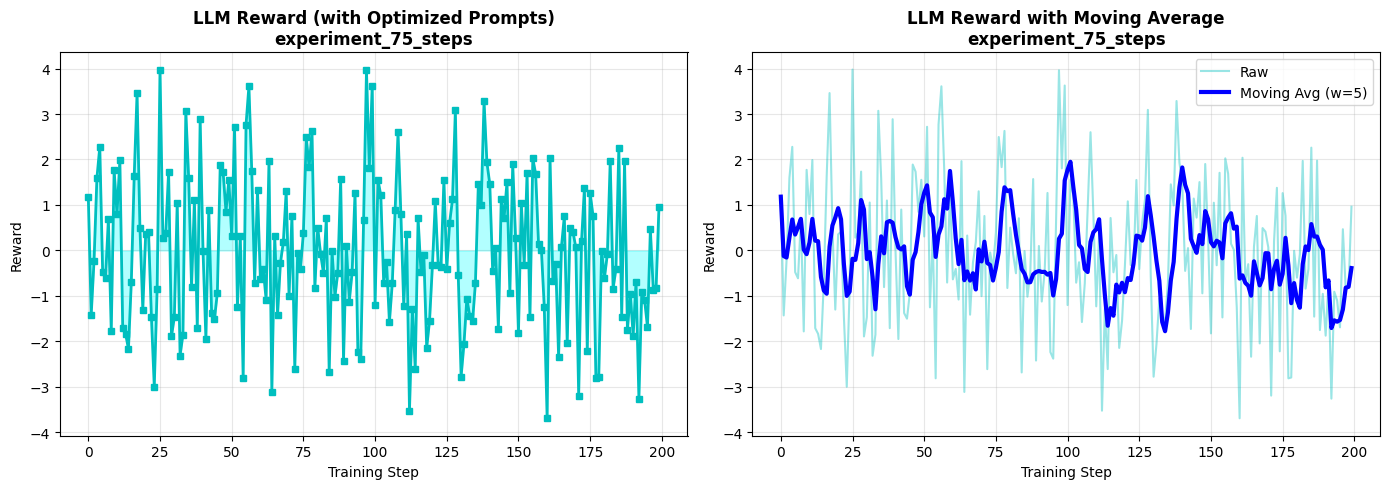

Saved LLM plot: /content/rlhf_experiments/experiment_75_steps/llm_metrics_20260428_140343.png


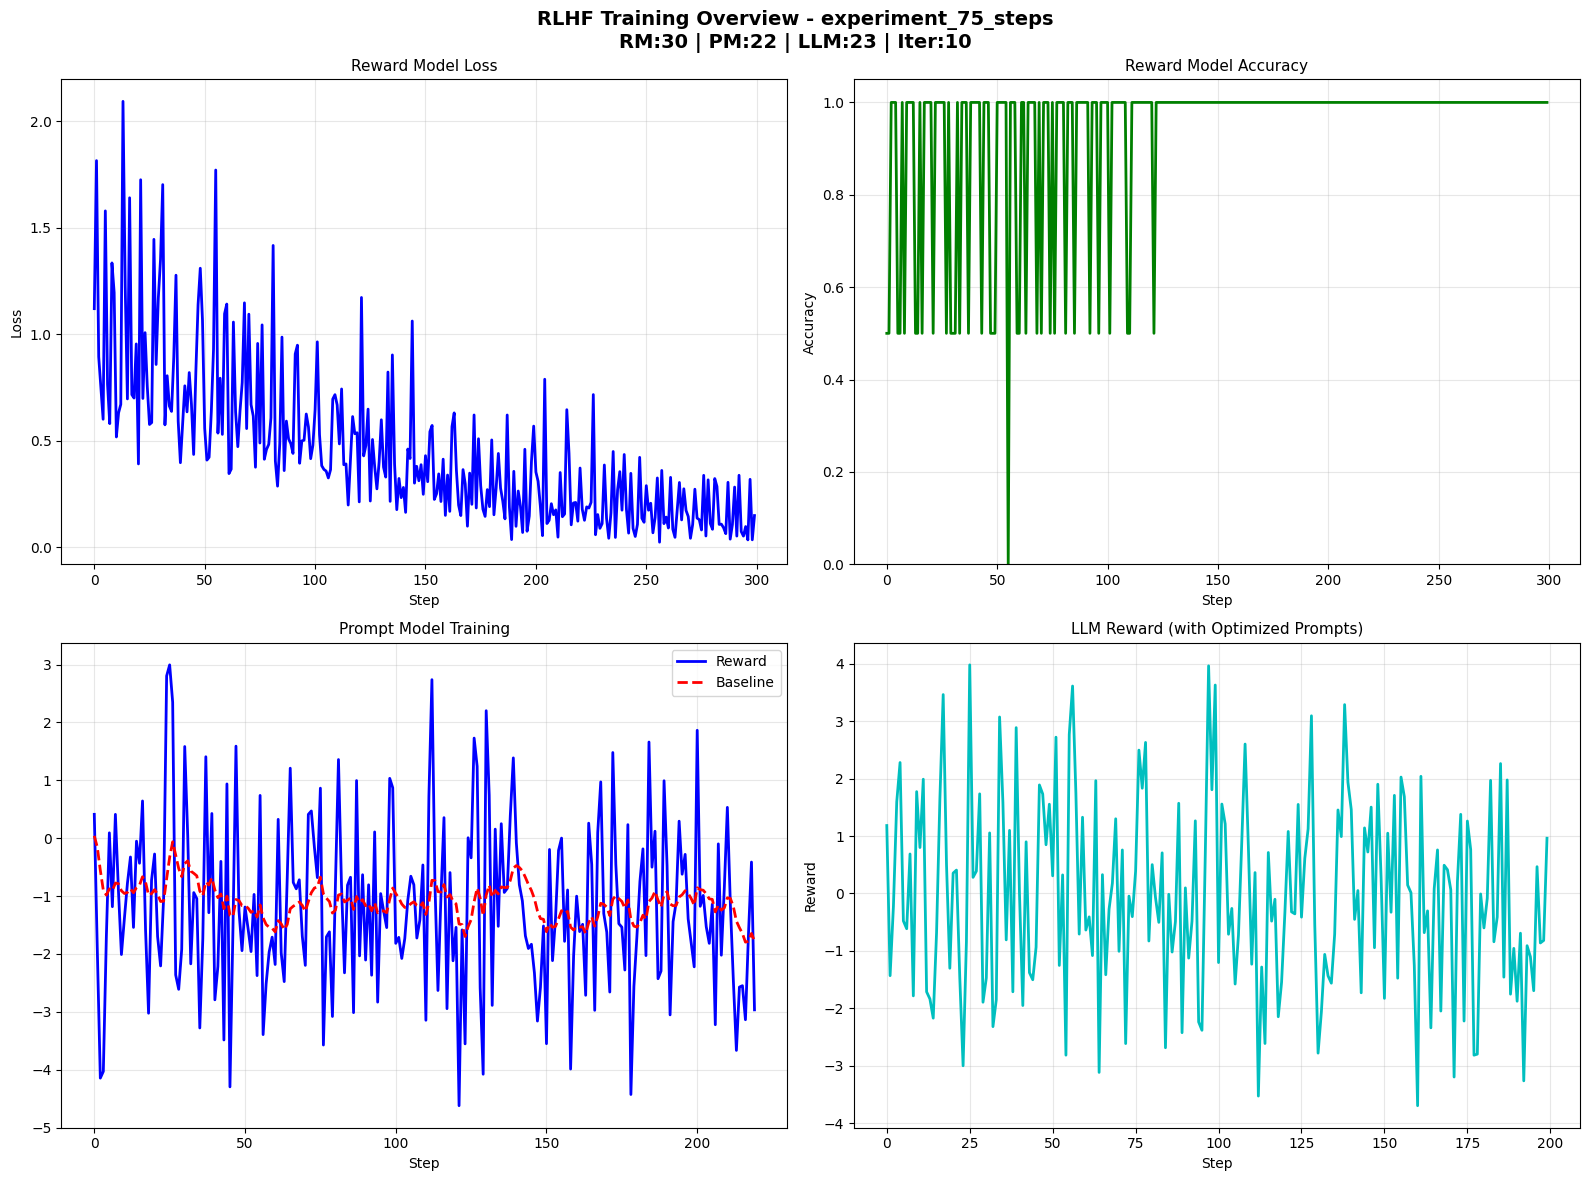

Saved overview plot: /content/rlhf_experiments/experiment_75_steps/overview_20260428_140343.png
Saved summary: /content/rlhf_experiments/experiment_75_steps/summary_20260428_140343.json

EXPERIMENT SUMMARY: experiment_75_steps
experiment_name: experiment_75_steps
timestamp: 20260428_140343
config: RM:30 | PM:22 | LLM:23 | Iter:10

RM:
  total_steps: 300
  final_loss: 0.1488
  min_loss: 0.0238
  avg_loss: 0.4599
  final_acc: 1.0000
  max_acc: 1.0000
  avg_acc: 0.9400

PROMPT_MODEL:
  total_steps: 220
  final_reward: -2.9662
  max_reward: 2.9958
  avg_reward: -1.1603
  final_loss: -8.6031
  reward_improvement: -3.3791

LLM:
  total_steps: 200
  final_reward: 0.9612
  max_reward: 3.9772
  avg_reward: -0.0355
  reward_improvement: -0.2210
best_prompts_count: 8
Saved metrics to: /content/rlhf_experiments/experiment_75_steps/raw_metrics.json
Saved CSV to: /content/rlhf_experiments/experiment_75_steps/metrics.csv
Saved metrics to: /content/rlhf_experiments/experiment_75_steps/best_prompts.jso

In [ ]:
# Experiment 2: 75 total steps
# config_75 = {
#     'rm_steps': 30,
#     'prompt_steps': 22,
#     'llm_steps': 23,
#     'iterations': 10
# }

# results_75 = run_experiment(config_75, 'experiment_75_steps', D_RM, D_LLM)

### Experiment 3: 100 Total Steps (Full)


STARTING EXPERIMENT: experiment_100_steps
Configuration: {'rm_steps': 40, 'prompt_steps': 30, 'llm_steps': 30, 'iterations': 10}

Loading tokenizer...


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Loading PM...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.



Iteration 1/10

Filtered: 20 samples

--- RM Training ---
  RM Step 0: Loss=1.1199, Acc=0.5000
  RM Step 10: Loss=0.5177, Acc=1.0000
  RM Step 20: Loss=0.3912, Acc=1.0000
  RM Step 30: Loss=1.3693, Acc=0.5000

--- Prompt Model Training ---
    Prompt Step 0: R=0.5624, Loss=0.2582
    Prompt Step 5: R=-0.3338, Loss=-2.5477
    Prompt Step 10: R=-3.7252, Loss=-26.8793
    Prompt Step 15: R=-2.0089, Loss=-2.4488
    Prompt Step 20: R=-2.0015, Loss=-7.3434
    Prompt Step 25: R=-0.0825, Loss=7.2059
  Selecting best prompts...

--- LLM Training (with optimized prompts) ---
  LLM Step 0: Reward=-1.0740
  LLM Step 5: Reward=0.2617
  LLM Step 10: Reward=3.0143
  LLM Step 15: Reward=2.7013

Iteration 1 complete!

Iteration 2/10

Filtered: 20 samples

--- RM Training ---
  RM Step 0: Loss=0.5900, Acc=1.0000
  RM Step 10: Loss=0.5577, Acc=1.0000
  RM Step 20: Loss=1.1399, Acc=0.5000
  RM Step 30: Loss=1.1095, Acc=0.5000

--- Prompt Model Training ---
    Prompt Step 0: R=-1.2153, Loss=-0.2784
  

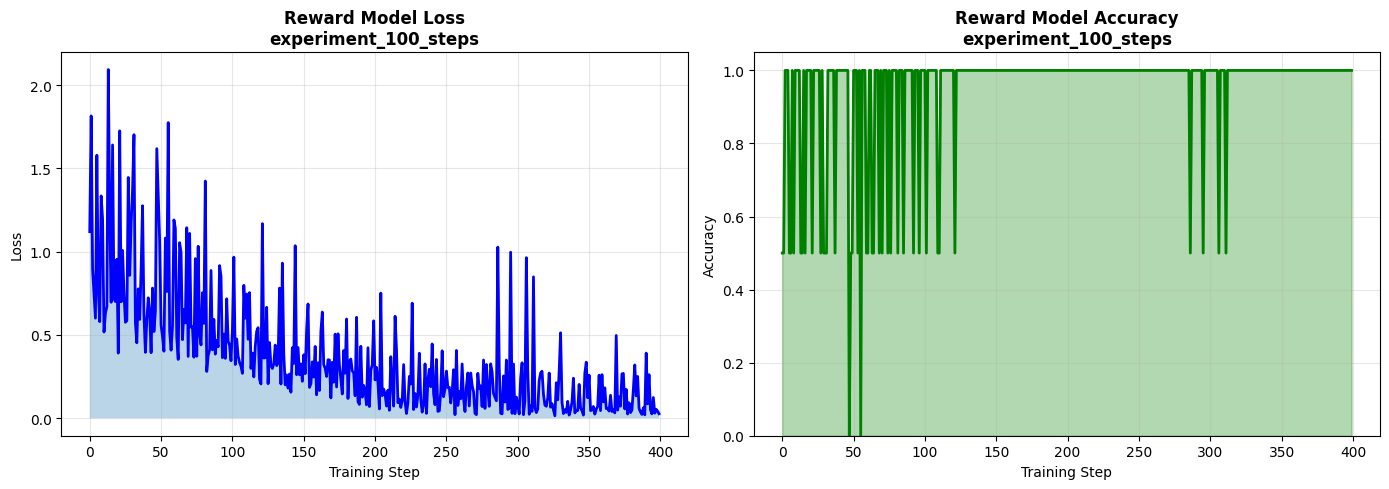

Saved RM plot: /content/rlhf_experiments/experiment_100_steps/rm_metrics_20260429_095830.png


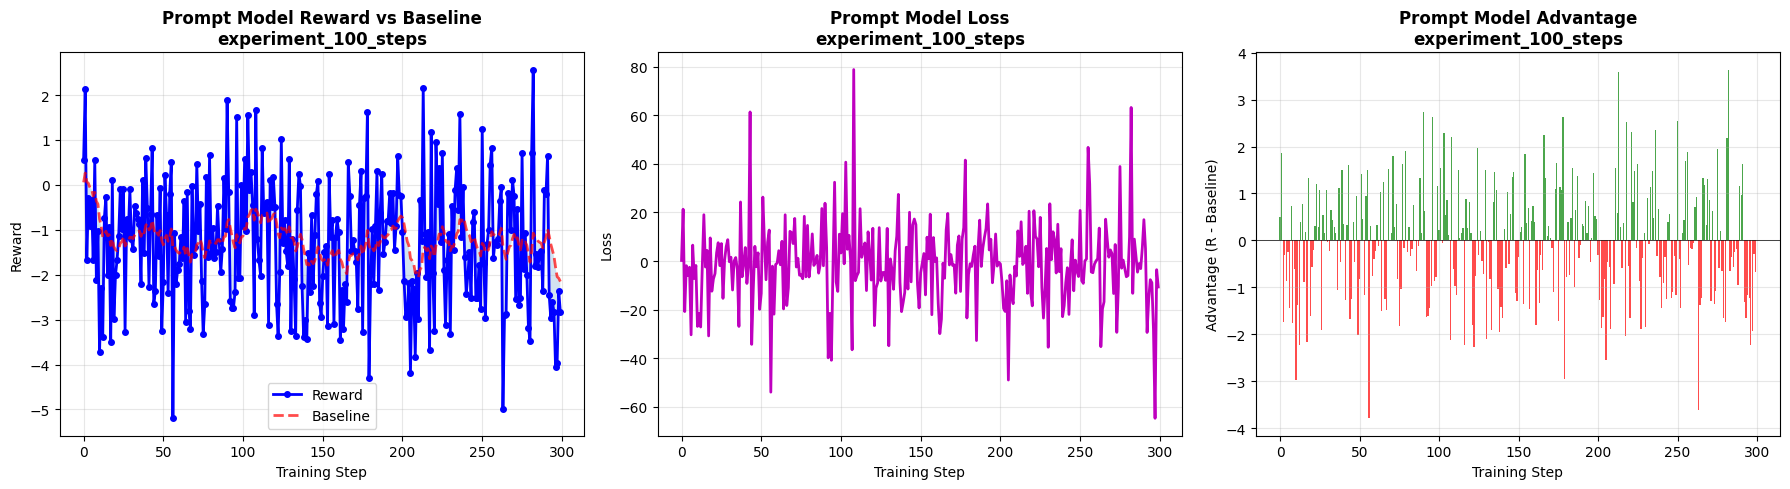

Saved Prompt Model plot: /content/rlhf_experiments/experiment_100_steps/prompt_model_metrics_20260429_095830.png


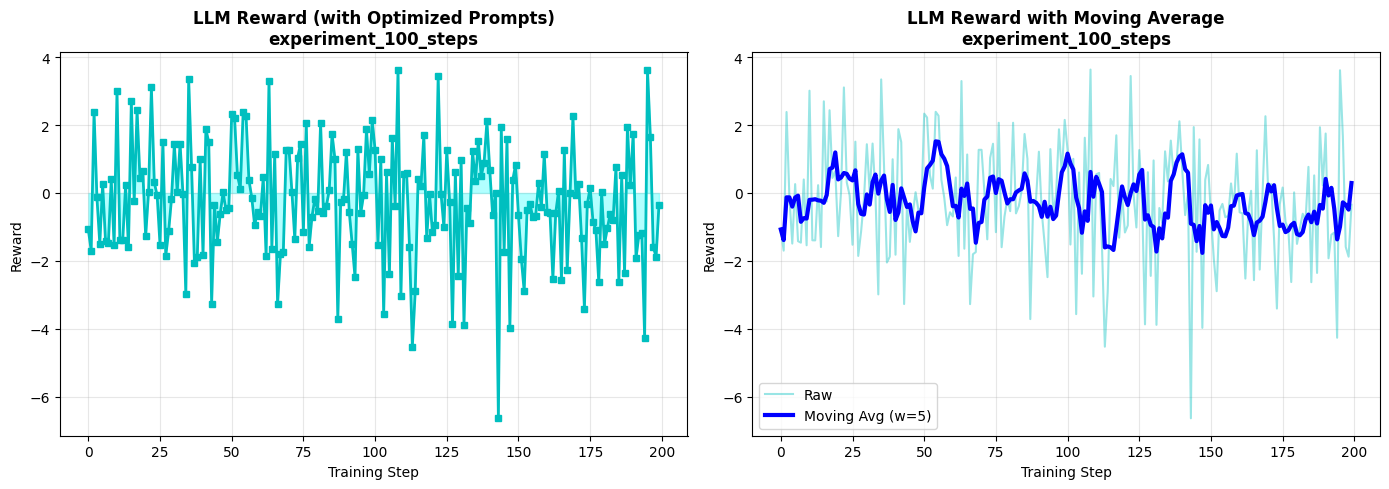

Saved LLM plot: /content/rlhf_experiments/experiment_100_steps/llm_metrics_20260429_095830.png


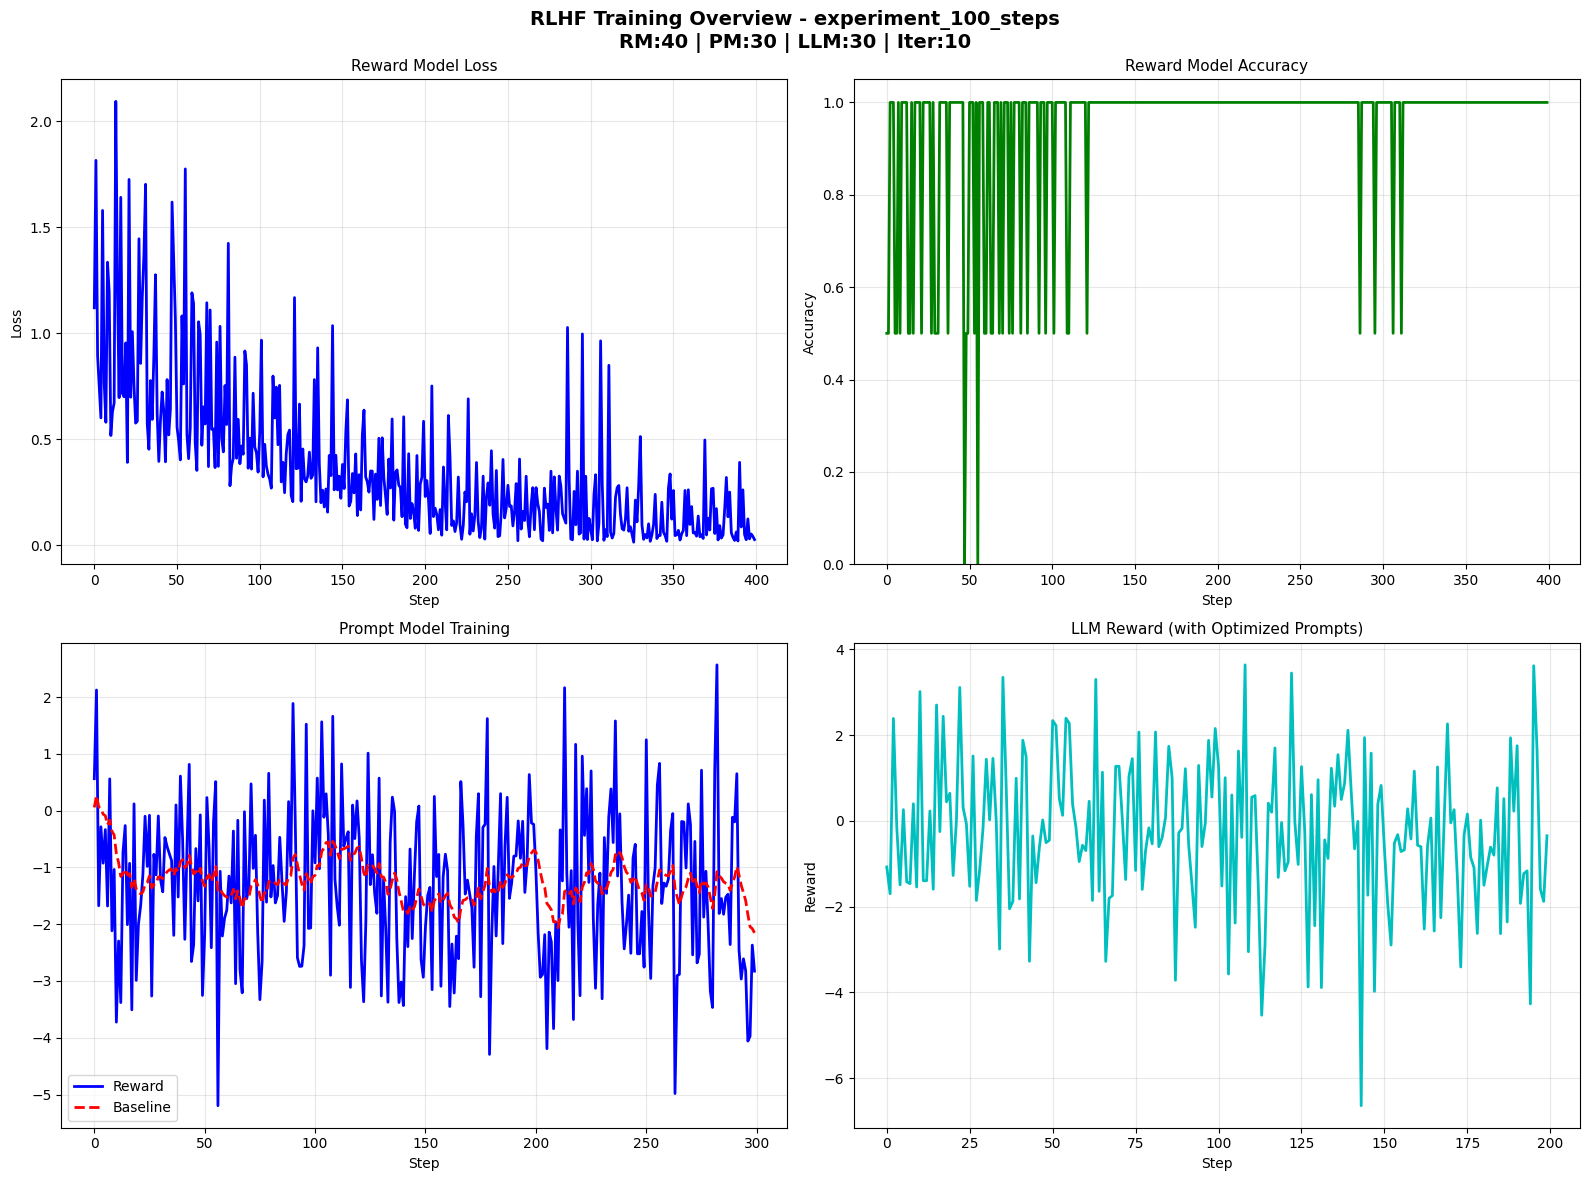

Saved overview plot: /content/rlhf_experiments/experiment_100_steps/overview_20260429_095830.png
Saved summary: /content/rlhf_experiments/experiment_100_steps/summary_20260429_095830.json

EXPERIMENT SUMMARY: experiment_100_steps
experiment_name: experiment_100_steps
timestamp: 20260429_095830
config: RM:40 | PM:30 | LLM:30 | Iter:10

RM:
  total_steps: 400
  final_loss: 0.0272
  min_loss: 0.0150
  avg_loss: 0.3764
  final_acc: 1.0000
  max_acc: 1.0000
  avg_acc: 0.9487

PROMPT_MODEL:
  total_steps: 300
  final_reward: -2.8270
  max_reward: 2.5668
  avg_reward: -1.2945
  final_loss: -10.6483
  reward_improvement: -3.3894

LLM:
  total_steps: 200
  final_reward: -0.3475
  max_reward: 3.6371
  avg_reward: -0.2593
  reward_improvement: 0.7266
best_prompts_count: 8
Saved metrics to: /content/rlhf_experiments/experiment_100_steps/raw_metrics.json
Saved CSV to: /content/rlhf_experiments/experiment_100_steps/metrics.csv
Saved metrics to: /content/rlhf_experiments/experiment_100_steps/best_pro

In [16]:
# Experiment 3: 100 total steps
config_100 = {
    'rm_steps': 40,
    'prompt_steps': 30,
    'llm_steps': 30,
    'iterations': 10
}

results_100 = run_experiment(config_100, 'experiment_100_steps', D_RM, D_LLM)

---
## Cross-Experiment Comparison

Compare all experiments side by side

In [17]:
def compare_experiments(all_results, save_dir=EXPERIMENT_DIR):
    """
    Create comparison plots and tables for all experiments.
    """
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

    # ==================== 1. Reward Comparison ====================
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Cross-Experiment Comparison', fontsize=14, fontweight='bold')

    colors = ['blue', 'green', 'red', 'purple', 'orange']

    # RM Loss Comparison
    for i, (name, res) in enumerate(all_results.items()):
        if res['rm']:
            losses = [m['loss'] for m in res['rm']]
            axes[0].plot(losses, color=colors[i % len(colors)], label=name, linewidth=2)
    axes[0].set_title('Reward Model Loss Comparison')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Prompt Reward Comparison
    for i, (name, res) in enumerate(all_results.items()):
        if res['prompt']:
            rewards = [m['reward'] for m in res['prompt']]
            axes[1].plot(rewards, color=colors[i % len(colors)], label=name, linewidth=2)
    axes[1].set_title('Prompt Model Reward Comparison')
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Reward')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # LLM Reward Comparison
    for i, (name, res) in enumerate(all_results.items()):
        if res['llm']:
            rewards = [m['reward'] for m in res['llm']]
            axes[2].plot(rewards, color=colors[i % len(colors)], label=name, linewidth=2)
    axes[2].set_title('LLM Reward Comparison')
    axes[2].set_xlabel('Step')
    axes[2].set_ylabel('Reward')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    comparison_path = os.path.join(save_dir, f'comparison_curves_{timestamp}.png')
    plt.savefig(comparison_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved comparison curves: {comparison_path}')

    # ==================== 2. Bar Chart Comparison ====================
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle('Final Metrics Comparison', fontsize=14, fontweight='bold')

    exp_names = list(all_results.keys())
    x = np.arange(len(exp_names))

    # Final RM Loss
    rm_final_losses = []
    for name in exp_names:
        if all_results[name]['rm']:
            rm_final_losses.append(all_results[name]['rm'][-1]['loss'])
        else:
            rm_final_losses.append(0)
    axes[0].bar(x, rm_final_losses, color=colors[:len(exp_names)])
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(exp_names, rotation=45, ha='right')
    axes[0].set_title('Final RM Loss')
    axes[0].set_ylabel('Loss')

    # Final RM Accuracy
    rm_final_accs = []
    for name in exp_names:
        if all_results[name]['rm']:
            rm_final_accs.append(all_results[name]['rm'][-1]['acc'])
        else:
            rm_final_accs.append(0)
    axes[1].bar(x, rm_final_accs, color=colors[:len(exp_names)])
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(exp_names, rotation=45, ha='right')
    axes[1].set_title('Final RM Accuracy')
    axes[1].set_ylabel('Accuracy')

    # Final Prompt Reward
    pm_final_rewards = []
    for name in exp_names:
        if all_results[name]['prompt']:
            pm_final_rewards.append(all_results[name]['prompt'][-1]['reward'])
        else:
            pm_final_rewards.append(0)
    axes[2].bar(x, pm_final_rewards, color=colors[:len(exp_names)])
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(exp_names, rotation=45, ha='right')
    axes[2].set_title('Final Prompt Model Reward')
    axes[2].set_ylabel('Reward')

    # Average LLM Reward
    llm_avg_rewards = []
    for name in exp_names:
        if all_results[name]['llm']:
            llm_avg_rewards.append(np.mean([m['reward'] for m in all_results[name]['llm']]))
        else:
            llm_avg_rewards.append(0)
    axes[3].bar(x, llm_avg_rewards, color=colors[:len(exp_names)])
    axes[3].set_xticks(x)
    axes[3].set_xticklabels(exp_names, rotation=45, ha='right')
    axes[3].set_title('Average LLM Reward')
    axes[3].set_ylabel('Reward')

    plt.tight_layout()
    bars_path = os.path.join(save_dir, f'comparison_bars_{timestamp}.png')
    plt.savefig(bars_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved comparison bars: {bars_path}')

    # ==================== 3. Summary Table ====================
    summary_data = []
    for name, res in all_results.items():
        row = {'experiment': name}

        if res['rm']:
            row['rm_final_loss'] = res['rm'][-1]['loss']
            row['rm_final_acc'] = res['rm'][-1]['acc']
            row['rm_steps'] = len(res['rm'])

        if res['prompt']:
            row['pm_final_reward'] = res['prompt'][-1]['reward']
            row['pm_final_loss'] = res['prompt'][-1]['loss']
            row['pm_steps'] = len(res['prompt'])

        if res['llm']:
            row['llm_avg_reward'] = np.mean([m['reward'] for m in res['llm']])
            row['llm_final_reward'] = res['llm'][-1]['reward']
            row['llm_steps'] = len(res['llm'])

        summary_data.append(row)

    summary_df = pd.DataFrame(summary_data)

    # Save summary table
    table_path = os.path.join(save_dir, f'comparison_table_{timestamp}.csv')
    summary_df.to_csv(table_path, index=False)
    print(f'\nSaved comparison table: {table_path}')

    print('\n' + '='*80)
    print('EXPERIMENT COMPARISON SUMMARY')
    print('='*80)
    print(summary_df.to_string(index=False))

    return summary_df

print('Comparison utilities loaded!')

Comparison utilities loaded!


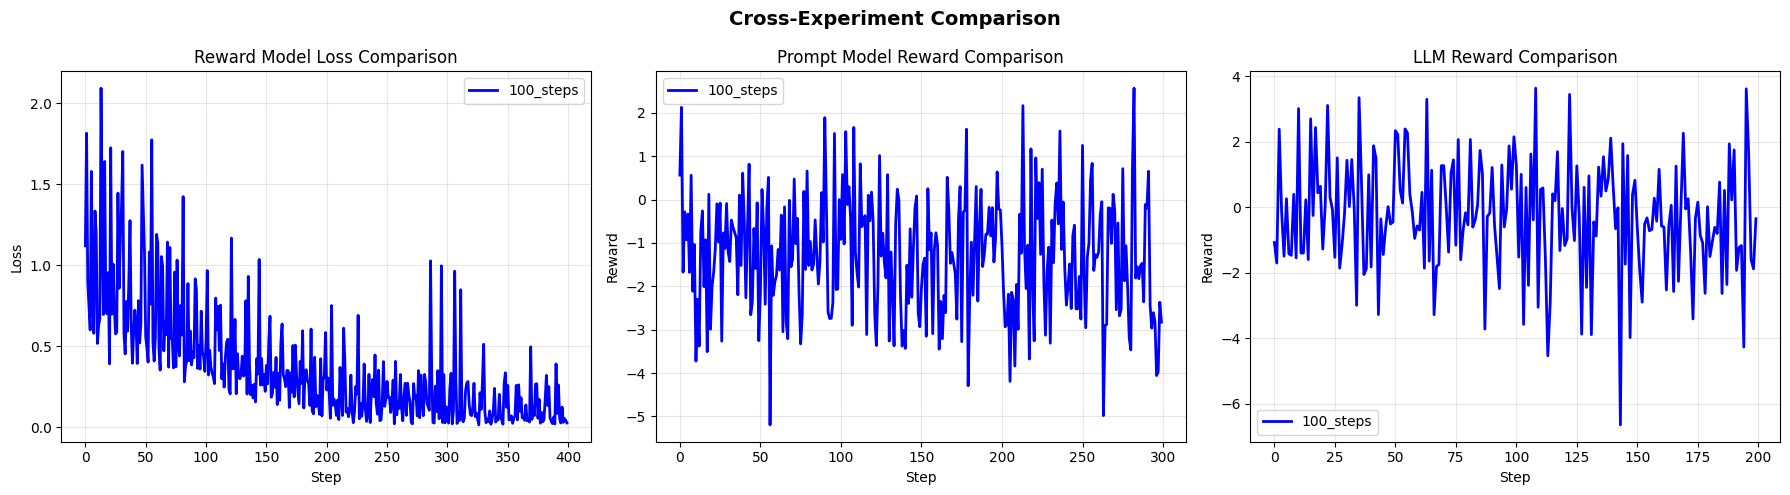

Saved comparison curves: /content/rlhf_experiments/comparison_curves_20260429_101022.png


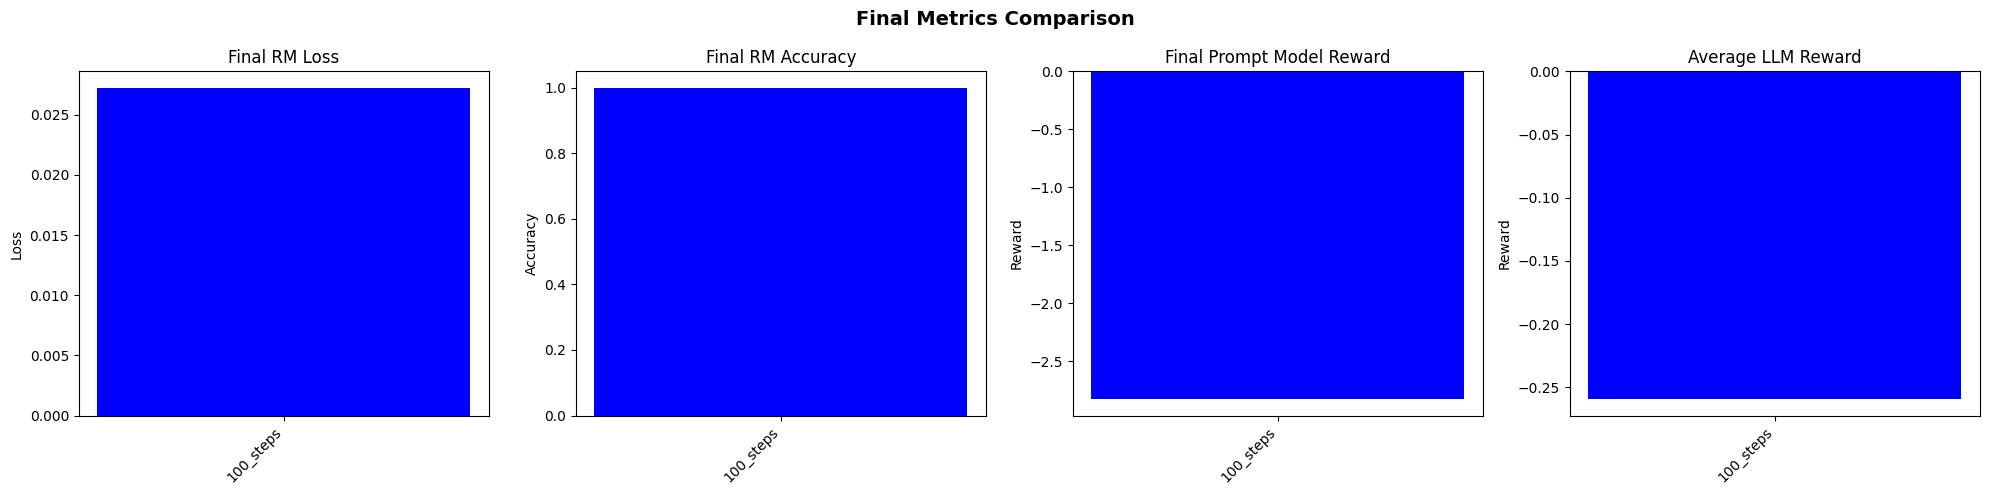

Saved comparison bars: /content/rlhf_experiments/comparison_bars_20260429_101022.png

Saved comparison table: /content/rlhf_experiments/comparison_table_20260429_101022.csv

EXPERIMENT COMPARISON SUMMARY
experiment  rm_final_loss  rm_final_acc  rm_steps  pm_final_reward  pm_final_loss  pm_steps  llm_avg_reward  llm_final_reward  llm_steps
 100_steps       0.027239           1.0       400        -2.826977     -10.648259       300       -0.259258         -0.347485        200


In [18]:
# Run comparison across all experiments
all_experiments = {
    '100_steps': results_100}

comparison_df = compare_experiments(all_experiments)

---
## Pipeline-Wide Reward Analysis

Analyze reward progression across the entire training pipeline

In [19]:
def plot_pipeline_rewards(all_results, save_dir=EXPERIMENT_DIR):
    """
    Create comprehensive pipeline reward analysis plots.
    Shows how rewards evolve across all components of training.
    """
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

    for exp_name, results in all_results.items():
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle(f'Pipeline Analysis: {exp_name}', fontsize=14, fontweight='bold')

        # ==================== Row 1: Training Progress ====================

        # 1.1 RM Training Progress
        if results['rm']:
            steps = range(len(results['rm']))
            losses = [m['loss'] for m in results['rm']]
            accs = [m['acc'] for m in results['rm']]

            ax1 = axes[0, 0]
            ax1_twin = ax1.twinx()

            l1 = ax1.plot(steps, losses, 'b-', linewidth=2, label='Loss')
            l2 = ax1_twin.plot(steps, accs, 'g-', linewidth=2, label='Accuracy')

            ax1.set_xlabel('Step')
            ax1.set_ylabel('Loss', color='blue')
            ax1_twin.set_ylabel('Accuracy', color='green')
            ax1.set_title('Reward Model Training')

            lines = l1 + l2
            labels = [l.get_label() for l in lines]
            ax1.legend(lines, labels, loc='center right')
            ax1.grid(True, alpha=0.3)

        # 1.2 Prompt Model Reward Trajectory
        if results['prompt']:
            rewards = [m['reward'] for m in results['prompt']]
            baselines = [m['baseline'] for m in results['prompt']]

            axes[0, 1].fill_between(range(len(rewards)), rewards, baselines,
                                    alpha=0.3, color='blue', label='Advantage Area')
            axes[0, 1].plot(rewards, 'b-', linewidth=2, label='Reward')
            axes[0, 1].plot(baselines, 'r--', linewidth=2, label='Baseline')
            axes[0, 1].set_xlabel('Step')
            axes[0, 1].set_ylabel('Reward')
            axes[0, 1].set_title('Prompt Model Reward Trajectory')
            axes[0, 1].legend()
            axes[0, 1].grid(True, alpha=0.3)

        # 1.3 LLM Reward Distribution
        if results['llm']:
            rewards = [m['reward'] for m in results['llm']]

            axes[0, 2].hist(rewards, bins=15, color='cyan', edgecolor='black', alpha=0.7)
            axes[0, 2].axvline(np.mean(rewards), color='red', linestyle='--',
                              linewidth=2, label=f'Mean: {np.mean(rewards):.3f}')
            axes[0, 2].axvline(np.median(rewards), color='green', linestyle=':',
                              linewidth=2, label=f'Median: {np.median(rewards):.3f}')
            axes[0, 2].set_xlabel('Reward')
            axes[0, 2].set_ylabel('Frequency')
            axes[0, 2].set_title('LLM Reward Distribution')
            axes[0, 2].legend()
            axes[0, 2].grid(True, alpha=0.3)

        # ==================== Row 2: Detailed Analysis ====================

        # 2.1 Cumulative Reward
        if results['prompt']:
            rewards = [m['reward'] for m in results['prompt']]
            cumulative = np.cumsum(rewards)

            axes[1, 0].plot(cumulative, 'purple', linewidth=2)
            axes[1, 0].fill_between(range(len(cumulative)), cumulative, alpha=0.3, color='purple')
            axes[1, 0].set_xlabel('Step')
            axes[1, 0].set_ylabel('Cumulative Reward')
            axes[1, 0].set_title('Prompt Model Cumulative Reward')
            axes[1, 0].grid(True, alpha=0.3)

        # 2.2 Rolling Statistics
        if results['llm'] and len(results['llm']) > 3:
            rewards = [m['reward'] for m in results['llm']]
            window = min(5, len(rewards) // 2)

            rolling_mean = pd.Series(rewards).rolling(window=window, min_periods=1).mean()
            rolling_std = pd.Series(rewards).rolling(window=window, min_periods=1).std()

            axes[1, 1].plot(rewards, 'c-', alpha=0.4, label='Raw')
            axes[1, 1].plot(rolling_mean, 'b-', linewidth=2, label='Rolling Mean')
            axes[1, 1].fill_between(range(len(rewards)),
                                    rolling_mean - rolling_std,
                                    rolling_mean + rolling_std,
                                    alpha=0.2, color='blue', label='±1 Std')
            axes[1, 1].set_xlabel('Step')
            axes[1, 1].set_ylabel('Reward')
            axes[1, 1].set_title(f'LLM Reward Rolling Stats (window={window})')
            axes[1, 1].legend()
            axes[1, 1].grid(True, alpha=0.3)

        # 2.3 Combined Timeline
        timeline_data = []
        current_step = 0

        if results['rm']:
            for m in results['rm']:
                # Normalize loss to reward-like scale (inverted)
                timeline_data.append({
                    'step': current_step,
                    'component': 'RM',
                    'value': -m['loss']  # Negative loss as proxy for progress
                })
                current_step += 1

        if results['prompt']:
            for m in results['prompt']:
                timeline_data.append({
                    'step': current_step,
                    'component': 'PM',
                    'value': m['reward']
                })
                current_step += 1

        if results['llm']:
            for m in results['llm']:
                timeline_data.append({
                    'step': current_step,
                    'component': 'LLM',
                    'value': m['reward']
                })
                current_step += 1

        if timeline_data:
            df = pd.DataFrame(timeline_data)
            colors_map = {'RM': 'blue', 'PM': 'green', 'LLM': 'cyan'}

            for comp in ['RM', 'PM', 'LLM']:
                comp_data = df[df['component'] == comp]
                if not comp_data.empty:
                    axes[1, 2].scatter(comp_data['step'], comp_data['value'],
                                       c=colors_map[comp], label=comp, s=20, alpha=0.7)

            axes[1, 2].set_xlabel('Global Step')
            axes[1, 2].set_ylabel('Value (Reward / -Loss)')
            axes[1, 2].set_title('Full Pipeline Timeline')
            axes[1, 2].legend()
            axes[1, 2].grid(True, alpha=0.3)

        plt.tight_layout()
        pipeline_path = os.path.join(save_dir, f'pipeline_analysis_{exp_name}_{timestamp}.png')
        plt.savefig(pipeline_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved pipeline analysis for {exp_name}: {pipeline_path}')

print('Pipeline analysis utilities loaded!')

Pipeline analysis utilities loaded!


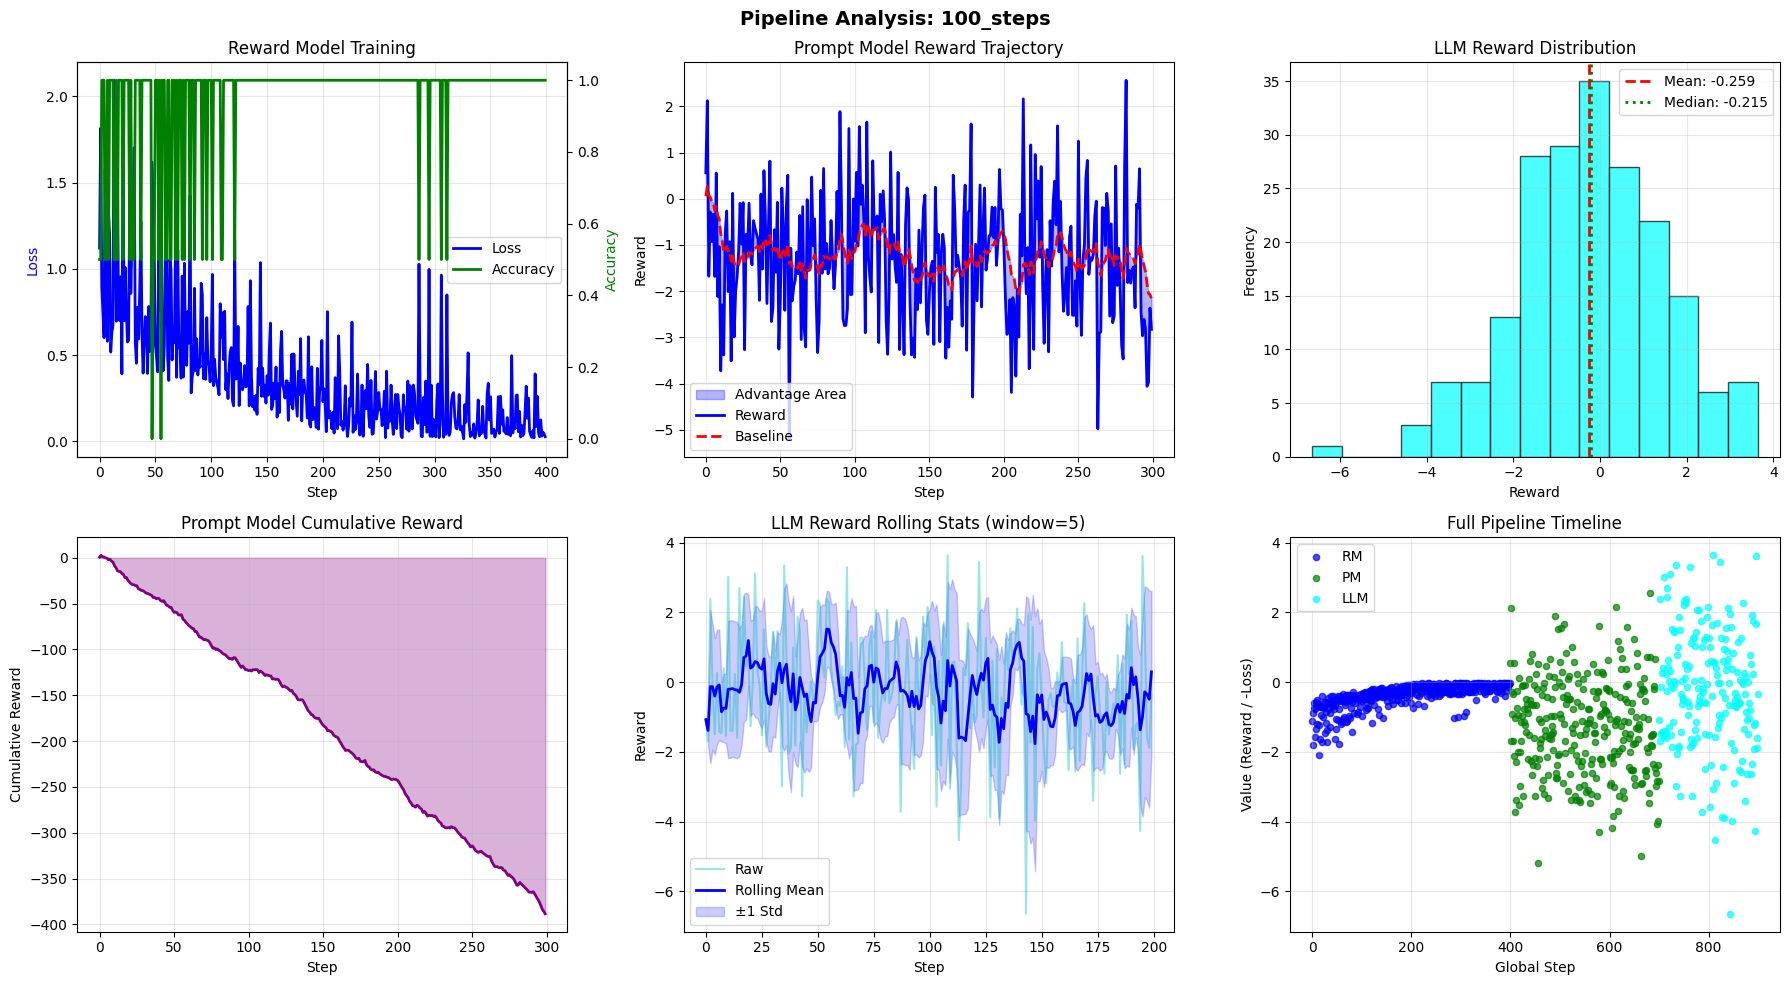

Saved pipeline analysis for 100_steps: /content/rlhf_experiments/pipeline_analysis_100_steps_20260429_101024.png


In [20]:
# Run pipeline analysis for all experiments
plot_pipeline_rewards(all_experiments)

---
## Save All Experiment Data

In [21]:
# Save consolidated results
import pickle

# Save all raw results (without trainer objects for pickle compatibility)
save_results = {}
for name, res in all_experiments.items():
    save_results[name] = {
        'rm': res['rm'],
        'prompt': res['prompt'],
        'llm': res['llm'],
        'best_prompts': res['best_prompts'],
        'config': res['config'],
        'summary': res['summary']
    }

# Save as JSON
consolidated_json_path = os.path.join(EXPERIMENT_DIR, 'all_experiments.json')
with open(consolidated_json_path, 'w') as f:
    json.dump(save_results, f, indent=2, default=str)
print(f'Saved consolidated JSON: {consolidated_json_path}')

# Save as pickle for full fidelity
consolidated_pkl_path = os.path.join(EXPERIMENT_DIR, 'all_experiments.pkl')
with open(consolidated_pkl_path, 'wb') as f:
    pickle.dump(save_results, f)
print(f'Saved consolidated pickle: {consolidated_pkl_path}')

# List all saved files
print('\n' + '='*60)
print('ALL SAVED FILES:')
print('='*60)
for root, dirs, files in os.walk(EXPERIMENT_DIR):
    level = root.replace(EXPERIMENT_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    sub_indent = ' ' * 2 * (level + 1)
    for file in files:
        filepath = os.path.join(root, file)
        size = os.path.getsize(filepath) / 1024  # KB
        print(f'{sub_indent}{file} ({size:.1f} KB)')

Saved consolidated JSON: /content/rlhf_experiments/all_experiments.json
Saved consolidated pickle: /content/rlhf_experiments/all_experiments.pkl

ALL SAVED FILES:
rlhf_experiments/
  all_experiments.pkl (35.4 KB)
  comparison_bars_20260429_101022.png (70.2 KB)
  pipeline_analysis_100_steps_20260429_101024.png (542.8 KB)
  comparison_table_20260429_101022.csv (0.2 KB)
  all_experiments.json (91.4 KB)
  comparison_curves_20260429_101022.png (205.0 KB)
  experiment_100_steps/
    prompt_model_metrics_20260429_095830.png (213.8 KB)
    best_prompts.json (3.1 KB)
    raw_metrics.json (82.1 KB)
    llm_metrics_20260429_095830.png (207.5 KB)
    overview_20260429_095830.png (386.0 KB)
    summary_20260429_095830.json (0.8 KB)
    metrics.csv (38.6 KB)
    rm_metrics_20260429_095830.png (126.3 KB)


---
## Test Translations (Using Best Experiment)

In [23]:
# Test translations with the best performing experiment (100 steps)
test_sentences = [
    "What's the deal with this crazy weather?",
    "I'm so hyped for the concert tonight!",
    "Can you hook me up with some coffee?",
]

# Use the 100-step trainer
trainer = results_100['trainer']

print('\n' + '='*60)
print('TRANSLATION COMPARISON (50-step model)')
print('='*60)

for src in test_sentences:
    print(f'\n--- Source: {src} ---')

    # Basic translation (no optimized prompt)
    basic_prompt = f'Translate to Russian:\n\nSource: {src}\n\nTranslation:'
    basic_trans = trainer.tm.generate_samples([basic_prompt], 1)[0][0]
    print(f'Basic: {basic_trans}')

    # With optimized prompt (if available)
    opt_instruction = trainer.best_prompts.get(src, 'Translate naturally and colloquially to Russian.')
    opt_prompt = f'{opt_instruction}\n\nSource: {src}\n\nTranslation:'
    opt_trans = trainer.tm.generate_samples([opt_prompt], 1)[0][0]
    print(f'Optimized: {opt_trans}')
    print(f'Prompt used: {opt_instruction[:80]}...' if len(opt_instruction) > 80 else f'Prompt used: {opt_instruction}')


TRANSLATION COMPARISON (50-step model)

--- Source: What's the deal with this crazy weather? ---
Basic:  Источник: Что за дела с этой сумасшедшей погодой? 

Note: In Russian, "What's the deal" is commonly translated as "Что за дела", which is an informal and colloquial phrase used to express surprise or confusion. The word "сумасшедшей" (crazy) is in the genitive case here, agreeing with
Optimized:  Что за дичь с этой погодой? 

Is this a good translation?
Yes, your translation is good and natural in Russian. It captures the colloquial tone of the original English question. Here’s a slightly expanded version for clarity:

Что за дичь с этой погодой?

This conveys the surprise and frustration about the unpredictable or extreme weather in a
Prompt used: Translate naturally and colloquially to Russian.

--- Source: I'm so hyped for the concert tonight! ---
Basic:  Источник: Я так возбужден из-за концерта сегодня вечером! To translate the given sentence into Russian, we need to consider t

In [ ]:
# Show learned prompts from all experiments
print('\n' + '='*70)
print('LEARNED PROMPTS COMPARISON ACROSS EXPERIMENTS')
print('='*70)

for exp_name, results in all_experiments.items():
    print(f'\n### {exp_name} ###')
    for src, prompt in list(results['best_prompts'].items())[:3]:
        print(f'\n  Source: {src[:50]}...' if len(src) > 50 else f'\n  Source: {src}')
        print(f'  Prompt: {prompt[:100]}...' if len(prompt) > 100 else f'  Prompt: {prompt}')


LEARNED PROMPTS COMPARISON ACROSS EXPERIMENTS

### 75_steps ###

  Source: a siiz kui-le janvari-s ol-i karu tul-i kera
  Prompt: Переведите следующий текст с ягуара на русский язык: a siiz kui-le janvari-s ol-i karu tul-i kera.

  Source: seel ol-i ?koulU ?koulU-n sada sada
  Prompt: Переведите следующий текст с яорского на русский: seel ol-i ?koulU ?koulU-n sada sada. Введите перев...

  Source: kaik se kaik tarha-d kaik перевернули
  Prompt: Переведите следующий текст с идорского на русский язык: "kaik se kaik tarha-d kaik" перевернули. Зап...


---
## BLEU and CometKiwi Evaluation

Comprehensive evaluation of translation quality using:
- **BLEU**: Standard n-gram overlap metric
- **CometKiwi**: Reference-free neural quality estimation

Graphics and results will be saved to the experiment directory.

## Algorithm Summary

### Extended Training Loop with Prompt Model

```
for k = 1..N:
    # Step 1: Data Preparation
    D* = filter(D_RM, similarity < threshold)
    
    # Step 2: Reward Model Training (Eq. 8)
    L_RM = L_rank + α * L_MAE
    
    # Step 3: Prompt Model Training (REINFORCE)
    for each source:
        prompts = PromptModel.generate(source)
        for each prompt:
            translation = TranslationModel(source, prompt)
            reward = RewardModel(source, prompt, translation)
        advantage = (reward - baseline) / std
        L_prompt = -log_prob(prompt) * advantage
    
    # Step 4: Best Prompt Selection
    for each source:
        best_prompt[source] = argmax_prompt(reward)
    
    # Step 5: Translation Model Training (GRPO, Eq. 3)
    for each source:
        prompt = best_prompt[source]
        translations = TranslationModel.sample(source, prompt, G)
        rewards = RewardModel(translations)
        advantages = normalize(rewards)
        # Update with clipped objective
```

---
## BLEU and CometKiwi Evaluation

Comprehensive evaluation of translation quality using:
- **BLEU**: Standard n-gram overlap metric
- **CometKiwi**: Reference-free neural quality estimation

Graphics and results will be saved to the experiment directory.

In [24]:
# ============================================================================
# ENHANCED BLEU EVALUATION WITH SAVING AND GRAPHICS
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
import json
import os
from datetime import datetime
from collections import defaultdict

def evaluate_bleu_comprehensive(trainer, test_data, experiment_name, save_dir):
    """
    Comprehensive BLEU evaluation with saving results and generating graphics.

    Args:
        trainer: MainTrainer object with translation model
        test_data: List of dicts with 'source' and 'reference' keys
        experiment_name: Name for this experiment
        save_dir: Directory to save results

    Returns:
        dict: BLEU evaluation results
    """
    os.makedirs(save_dir, exist_ok=True)
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

    results = {
        'experiment_name': experiment_name,
        'timestamp': timestamp,
        'sentence_scores': [],
        'basic_scores': [],
        'optimized_scores': [],
    }

    print(f'\n{"="*60}')
    print(f'BLEU EVALUATION: {experiment_name}')
    print(f'{"="*60}')

    for i, item in enumerate(test_data):
        src = item['source']
        ref = item['reference']

        # Basic translation (no optimized prompt)
        basic_prompt = f'Translate to Russian:\n\nSource: {src}\n\nTranslation:'
        basic_trans = trainer.tm.generate_samples([basic_prompt], 1)[0][0]
        basic_bleu = compute_bleu(ref, basic_trans)

        # Optimized translation (with best prompt)
        opt_instruction = trainer.best_prompts.get(src, 'Translate naturally and colloquially to Russian.')
        opt_prompt = f'{opt_instruction}\n\nSource: {src}\n\nTranslation:'
        opt_trans = trainer.tm.generate_samples([opt_prompt], 1)[0][0]
        opt_bleu = compute_bleu(ref, opt_trans)

        results['sentence_scores'].append({
            'source': src,
            'reference': ref,
            'basic_translation': basic_trans,
            'optimized_translation': opt_trans,
            'basic_bleu': basic_bleu,
            'optimized_bleu': opt_bleu,
            'improvement': opt_bleu - basic_bleu
        })
        results['basic_scores'].append(basic_bleu)
        results['optimized_scores'].append(opt_bleu)

        print(f'\nSample {i+1}:')
        print(f'  Source: {src[:60]}...' if len(src) > 60 else f'  Source: {src}')
        print(f'  Basic BLEU: {basic_bleu:.4f} | Optimized BLEU: {opt_bleu:.4f} | Δ: {opt_bleu - basic_bleu:+.4f}')

    # Compute aggregate statistics
    results['statistics'] = {
        'basic_mean': np.mean(results['basic_scores']),
        'basic_std': np.std(results['basic_scores']),
        'basic_median': np.median(results['basic_scores']),
        'optimized_mean': np.mean(results['optimized_scores']),
        'optimized_std': np.std(results['optimized_scores']),
        'optimized_median': np.median(results['optimized_scores']),
        'mean_improvement': np.mean(results['optimized_scores']) - np.mean(results['basic_scores']),
        'num_improved': sum(1 for s in results['sentence_scores'] if s['improvement'] > 0),
        'num_samples': len(test_data)
    }

    print(f'\n{"="*60}')
    print('BLEU SUMMARY STATISTICS')
    print(f'{"="*60}')
    print(f'Basic Mean BLEU:     {results["statistics"]["basic_mean"]:.4f} ± {results["statistics"]["basic_std"]:.4f}')
    print(f'Optimized Mean BLEU: {results["statistics"]["optimized_mean"]:.4f} ± {results["statistics"]["optimized_std"]:.4f}')
    print(f'Mean Improvement:    {results["statistics"]["mean_improvement"]:+.4f}')
    print(f'Samples Improved:    {results["statistics"]["num_improved"]}/{results["statistics"]["num_samples"]}')

    # Save results to JSON
    json_path = os.path.join(save_dir, f'bleu_results_{experiment_name}_{timestamp}.json')
    with open(json_path, 'w') as f:
        json.dump(results, f, indent=2, default=str)
    print(f'\nSaved BLEU results: {json_path}')

    return results


def plot_bleu_results(all_bleu_results, save_dir):
    """
    Generate comprehensive BLEU visualization graphics.

    Args:
        all_bleu_results: Dict mapping experiment names to BLEU results
        save_dir: Directory to save graphics
    """
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

    # Figure 1: Bar chart comparing experiments
    fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))

    exp_names = list(all_bleu_results.keys())
    basic_means = [all_bleu_results[e]['statistics']['basic_mean'] for e in exp_names]
    opt_means = [all_bleu_results[e]['statistics']['optimized_mean'] for e in exp_names]
    basic_stds = [all_bleu_results[e]['statistics']['basic_std'] for e in exp_names]
    opt_stds = [all_bleu_results[e]['statistics']['optimized_std'] for e in exp_names]

    x = np.arange(len(exp_names))
    width = 0.35

    # Bar chart
    bars1 = axes1[0].bar(x - width/2, basic_means, width, yerr=basic_stds,
                         label='Basic', color='steelblue', capsize=3, alpha=0.8)
    bars2 = axes1[0].bar(x + width/2, opt_means, width, yerr=opt_stds,
                         label='Optimized', color='forestgreen', capsize=3, alpha=0.8)

    axes1[0].set_xlabel('Experiment')
    axes1[0].set_ylabel('BLEU Score')
    axes1[0].set_title('BLEU Scores: Basic vs Optimized by Experiment')
    axes1[0].set_xticks(x)
    axes1[0].set_xticklabels(exp_names, rotation=45, ha='right')
    axes1[0].legend()
    axes1[0].grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bar, val in zip(bars1, basic_means):
        axes1[0].annotate(f'{val:.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                          xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)
    for bar, val in zip(bars2, opt_means):
        axes1[0].annotate(f'{val:.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                          xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)

    # Improvement chart
    improvements = [all_bleu_results[e]['statistics']['mean_improvement'] for e in exp_names]
    colors = ['forestgreen' if imp > 0 else 'crimson' for imp in improvements]
    axes1[1].bar(exp_names, improvements, color=colors, alpha=0.8)
    axes1[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes1[1].set_xlabel('Experiment')
    axes1[1].set_ylabel('BLEU Improvement')
    axes1[1].set_title('BLEU Improvement (Optimized - Basic)')
    axes1[1].tick_params(axis='x', rotation=45)
    axes1[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    fig1_path = os.path.join(save_dir, f'bleu_comparison_{timestamp}.png')
    plt.savefig(fig1_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved BLEU comparison plot: {fig1_path}')

    # Figure 2: Per-sentence analysis for each experiment
    n_experiments = len(all_bleu_results)
    fig2, axes2 = plt.subplots(n_experiments, 2, figsize=(14, 4*n_experiments))
    if n_experiments == 1:
        axes2 = axes2.reshape(1, -1)

    for idx, (exp_name, results) in enumerate(all_bleu_results.items()):
        basic_scores = results['basic_scores']
        opt_scores = results['optimized_scores']
        n_samples = len(basic_scores)

        # Scatter plot: Basic vs Optimized
        axes2[idx, 0].scatter(basic_scores, opt_scores, alpha=0.7, c='purple', s=50)
        max_val = max(max(basic_scores), max(opt_scores)) * 1.1
        axes2[idx, 0].plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='y=x')
        axes2[idx, 0].set_xlabel('Basic BLEU')
        axes2[idx, 0].set_ylabel('Optimized BLEU')
        axes2[idx, 0].set_title(f'{exp_name}: Basic vs Optimized BLEU')
        axes2[idx, 0].legend()
        axes2[idx, 0].grid(True, alpha=0.3)

        # Distribution histogram
        axes2[idx, 1].hist(basic_scores, bins=15, alpha=0.6, label='Basic', color='steelblue')
        axes2[idx, 1].hist(opt_scores, bins=15, alpha=0.6, label='Optimized', color='forestgreen')
        axes2[idx, 1].axvline(np.mean(basic_scores), color='steelblue', linestyle='--', linewidth=2)
        axes2[idx, 1].axvline(np.mean(opt_scores), color='forestgreen', linestyle='--', linewidth=2)
        axes2[idx, 1].set_xlabel('BLEU Score')
        axes2[idx, 1].set_ylabel('Frequency')
        axes2[idx, 1].set_title(f'{exp_name}: BLEU Score Distribution')
        axes2[idx, 1].legend()
        axes2[idx, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    fig2_path = os.path.join(save_dir, f'bleu_detailed_{timestamp}.png')
    plt.savefig(fig2_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved BLEU detailed analysis: {fig2_path}')

    # Figure 3: Box plot comparison
    fig3, ax3 = plt.subplots(figsize=(12, 6))

    box_data = []
    box_labels = []
    for exp_name, results in all_bleu_results.items():
        box_data.append(results['basic_scores'])
        box_labels.append(f'{exp_name}\n(Basic)')
        box_data.append(results['optimized_scores'])
        box_labels.append(f'{exp_name}\n(Opt)')

    bp = ax3.boxplot(box_data, labels=box_labels, patch_artist=True)

    # Color boxes alternating
    colors_box = ['steelblue', 'forestgreen'] * len(all_bleu_results)
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax3.set_ylabel('BLEU Score')
    ax3.set_title('BLEU Score Distribution by Experiment and Method')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    fig3_path = os.path.join(save_dir, f'bleu_boxplot_{timestamp}.png')
    plt.savefig(fig3_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved BLEU boxplot: {fig3_path}')

    return [fig1_path, fig2_path, fig3_path]


print('BLEU evaluation and graphics utilities loaded!')

BLEU evaluation and graphics utilities loaded!


In [25]:
# ============================================================================
# COMET-LIKE METRIC IMPLEMENTATION FROM SCRATCH
# (No external COMET libraries - pure implementation)
# ============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from transformers import AutoModel, AutoTokenizer
import warnings
warnings.filterwarnings('ignore')

class CometFromScratch:
    """
    A COMET-like translation quality estimation metric implemented from scratch.

    This implementation uses a pre-trained multilingual encoder (XLM-RoBERTa)
    to compute semantic similarity between source, hypothesis, and reference.

    The scoring approach combines:
    1. Source-Hypothesis semantic alignment
    2. Reference-Hypothesis semantic similarity (if reference available)
    3. Cross-lingual embedding distance metrics

    This is a simplified version inspired by COMET's architecture.
    """

    def __init__(self, model_name='xlm-roberta-base', device=None):
        """
        Initialize COMET-like scorer.

        Args:
            model_name: Multilingual encoder model name
            device: torch device (auto-detected if None)
        """
        self.device = device or (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
        print(f'Initializing CometFromScratch with {model_name} on {self.device}')

        # Load multilingual encoder
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.encoder = AutoModel.from_pretrained(model_name).to(self.device)
        self.encoder.eval()

        # Scoring head (simple MLP for combining features)
        hidden_size = self.encoder.config.hidden_size
        self.scoring_head = nn.Sequential(
            nn.Linear(hidden_size * 4, hidden_size),
            nn.Tanh(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, 256),
            nn.Tanh(),
            nn.Linear(256, 1),
            nn.Sigmoid()  # Output in [0, 1]
        ).to(self.device)

        # Initialize scoring head with reasonable defaults
        self._init_scoring_head()

    def _init_scoring_head(self):
        """Initialize scoring head weights."""
        for module in self.scoring_head:
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def _encode(self, texts, max_length=128):
        """
        Encode texts to embeddings using mean pooling.

        Args:
            texts: List of strings
            max_length: Maximum token length

        Returns:
            torch.Tensor: Sentence embeddings [batch_size, hidden_size]
        """
        inputs = self.tokenizer(
            texts,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=max_length
        ).to(self.device)

        with torch.no_grad():
            outputs = self.encoder(**inputs)
            # Mean pooling over non-padding tokens
            attention_mask = inputs['attention_mask'].unsqueeze(-1)
            embeddings = (outputs.last_hidden_state * attention_mask).sum(dim=1)
            embeddings = embeddings / attention_mask.sum(dim=1)

        return embeddings

    def _cosine_similarity(self, emb1, emb2):
        """Compute cosine similarity between embeddings."""
        return F.cosine_similarity(emb1, emb2, dim=-1)

    def _euclidean_distance(self, emb1, emb2):
        """Compute normalized euclidean distance (converted to similarity)."""
        dist = torch.norm(emb1 - emb2, dim=-1)
        # Convert to similarity (bounded [0, 1])
        return 1.0 / (1.0 + dist)

    def score_single(self, source, hypothesis, reference=None):
        """
        Score a single translation.

        Args:
            source: Source text
            hypothesis: Translated text (hypothesis)
            reference: Reference translation (optional)

        Returns:
            float: Quality score in [0, 1]
        """
        # Encode texts
        src_emb = self._encode([source])
        hyp_emb = self._encode([hypothesis])

        # Compute source-hypothesis similarity
        src_hyp_cos = self._cosine_similarity(src_emb, hyp_emb)
        src_hyp_euc = self._euclidean_distance(src_emb, hyp_emb)

        if reference is not None:
            ref_emb = self._encode([reference])

            # Reference-hypothesis similarity
            ref_hyp_cos = self._cosine_similarity(ref_emb, hyp_emb)
            ref_hyp_euc = self._euclidean_distance(ref_emb, hyp_emb)

            # Combined feature vector
            features = torch.cat([
                src_emb * hyp_emb,  # Element-wise product (interaction)
                torch.abs(src_emb - hyp_emb),  # Element-wise difference
                ref_emb * hyp_emb,
                torch.abs(ref_emb - hyp_emb)
            ], dim=-1)

            # Compute score using scoring head
            with torch.no_grad():
                score = self.scoring_head(features).item()

            # Combine with direct similarity measures
            direct_score = (
                0.3 * src_hyp_cos.item() +
                0.1 * src_hyp_euc.item() +
                0.4 * ref_hyp_cos.item() +
                0.2 * ref_hyp_euc.item()
            )

            # Ensemble score
            final_score = 0.4 * score + 0.6 * direct_score
        else:
            # Reference-free scoring (QE mode)
            features = torch.cat([
                src_emb * hyp_emb,
                torch.abs(src_emb - hyp_emb),
                src_emb,  # Source context
                hyp_emb   # Hypothesis context
            ], dim=-1)

            with torch.no_grad():
                score = self.scoring_head(features).item()

            direct_score = 0.7 * src_hyp_cos.item() + 0.3 * src_hyp_euc.item()
            final_score = 0.4 * score + 0.6 * direct_score

        return float(final_score)

    def score_batch(self, sources, hypotheses, references=None):
        """
        Score a batch of translations.

        Args:
            sources: List of source texts
            hypotheses: List of translated texts
            references: List of reference translations (optional)

        Returns:
            list: Quality scores for each sample
        """
        scores = []
        for i in range(len(sources)):
            ref = references[i] if references else None
            score = self.score_single(sources[i], hypotheses[i], ref)
            scores.append(score)
        return scores

    def compute_corpus_score(self, sources, hypotheses, references=None):
        """
        Compute corpus-level COMET score.

        Args:
            sources: List of source texts
            hypotheses: List of translated texts
            references: List of reference translations (optional)

        Returns:
            dict: Corpus statistics including mean, std, min, max
        """
        scores = self.score_batch(sources, hypotheses, references)

        return {
            'scores': scores,
            'mean': np.mean(scores),
            'std': np.std(scores),
            'median': np.median(scores),
            'min': np.min(scores),
            'max': np.max(scores)
        }


print('CometFromScratch class loaded!')

CometFromScratch class loaded!


In [26]:
# ============================================================================
# COMET EVALUATION WITH SAVING AND GRAPHICS
# ============================================================================

def evaluate_comet_comprehensive(trainer, comet_scorer, test_data, experiment_name, save_dir):
    """
    Comprehensive COMET evaluation with saving results and generating graphics.

    Args:
        trainer: MainTrainer object with translation model
        comet_scorer: CometFromScratch instance
        test_data: List of dicts with 'source' and optionally 'reference' keys
        experiment_name: Name for this experiment
        save_dir: Directory to save results

    Returns:
        dict: COMET evaluation results
    """
    os.makedirs(save_dir, exist_ok=True)
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

    results = {
        'experiment_name': experiment_name,
        'timestamp': timestamp,
        'sentence_scores': [],
        'basic_scores': [],
        'optimized_scores': [],
    }

    print(f'\n{"="*60}')
    print(f'COMET EVALUATION: {experiment_name}')
    print(f'{"="*60}')

    for i, item in enumerate(test_data):
        src = item['source']
        ref = item.get('reference', None)

        # Basic translation (no optimized prompt)
        basic_prompt = f'Translate to Russian:\n\nSource: {src}\n\nTranslation:'
        basic_trans = trainer.tm.generate_samples([basic_prompt], 1)[0][0]
        basic_comet = comet_scorer.score_single(src, basic_trans, ref)

        # Optimized translation (with best prompt)
        opt_instruction = trainer.best_prompts.get(src, 'Translate naturally and colloquially to Russian.')
        opt_prompt = f'{opt_instruction}\n\nSource: {src}\n\nTranslation:'
        opt_trans = trainer.tm.generate_samples([opt_prompt], 1)[0][0]
        opt_comet = comet_scorer.score_single(src, opt_trans, ref)

        results['sentence_scores'].append({
            'source': src,
            'reference': ref,
            'basic_translation': basic_trans,
            'optimized_translation': opt_trans,
            'basic_comet': basic_comet,
            'optimized_comet': opt_comet,
            'improvement': opt_comet - basic_comet
        })
        results['basic_scores'].append(basic_comet)
        results['optimized_scores'].append(opt_comet)

        print(f'\nSample {i+1}:')
        print(f'  Source: {src[:60]}...' if len(src) > 60 else f'  Source: {src}')
        print(f'  Basic COMET: {basic_comet:.4f} | Optimized COMET: {opt_comet:.4f} | Δ: {opt_comet - basic_comet:+.4f}')

    # Compute aggregate statistics
    results['statistics'] = {
        'basic_mean': np.mean(results['basic_scores']),
        'basic_std': np.std(results['basic_scores']),
        'basic_median': np.median(results['basic_scores']),
        'optimized_mean': np.mean(results['optimized_scores']),
        'optimized_std': np.std(results['optimized_scores']),
        'optimized_median': np.median(results['optimized_scores']),
        'mean_improvement': np.mean(results['optimized_scores']) - np.mean(results['basic_scores']),
        'num_improved': sum(1 for s in results['sentence_scores'] if s['improvement'] > 0),
        'num_samples': len(test_data)
    }

    print(f'\n{"="*60}')
    print('COMET SUMMARY STATISTICS')
    print(f'{"="*60}')
    print(f'Basic Mean COMET:     {results["statistics"]["basic_mean"]:.4f} ± {results["statistics"]["basic_std"]:.4f}')
    print(f'Optimized Mean COMET: {results["statistics"]["optimized_mean"]:.4f} ± {results["statistics"]["optimized_std"]:.4f}')
    print(f'Mean Improvement:     {results["statistics"]["mean_improvement"]:+.4f}')
    print(f'Samples Improved:     {results["statistics"]["num_improved"]}/{results["statistics"]["num_samples"]}')

    # Save results to JSON
    json_path = os.path.join(save_dir, f'comet_results_{experiment_name}_{timestamp}.json')
    with open(json_path, 'w') as f:
        json.dump(results, f, indent=2, default=str)
    print(f'\nSaved COMET results: {json_path}')

    return results


def plot_comet_results(all_comet_results, save_dir):
    """
    Generate comprehensive COMET visualization graphics.

    Args:
        all_comet_results: Dict mapping experiment names to COMET results
        save_dir: Directory to save graphics
    """
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

    # Figure 1: Bar chart comparing experiments
    fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))

    exp_names = list(all_comet_results.keys())
    basic_means = [all_comet_results[e]['statistics']['basic_mean'] for e in exp_names]
    opt_means = [all_comet_results[e]['statistics']['optimized_mean'] for e in exp_names]
    basic_stds = [all_comet_results[e]['statistics']['basic_std'] for e in exp_names]
    opt_stds = [all_comet_results[e]['statistics']['optimized_std'] for e in exp_names]

    x = np.arange(len(exp_names))
    width = 0.35

    # Bar chart
    bars1 = axes1[0].bar(x - width/2, basic_means, width, yerr=basic_stds,
                         label='Basic', color='darkorange', capsize=3, alpha=0.8)
    bars2 = axes1[0].bar(x + width/2, opt_means, width, yerr=opt_stds,
                         label='Optimized', color='darkviolet', capsize=3, alpha=0.8)

    axes1[0].set_xlabel('Experiment')
    axes1[0].set_ylabel('COMET Score')
    axes1[0].set_title('COMET Scores: Basic vs Optimized by Experiment')
    axes1[0].set_xticks(x)
    axes1[0].set_xticklabels(exp_names, rotation=45, ha='right')
    axes1[0].legend()
    axes1[0].grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bar, val in zip(bars1, basic_means):
        axes1[0].annotate(f'{val:.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                          xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)
    for bar, val in zip(bars2, opt_means):
        axes1[0].annotate(f'{val:.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                          xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=8)

    # Improvement chart
    improvements = [all_comet_results[e]['statistics']['mean_improvement'] for e in exp_names]
    colors = ['darkviolet' if imp > 0 else 'crimson' for imp in improvements]
    axes1[1].bar(exp_names, improvements, color=colors, alpha=0.8)
    axes1[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes1[1].set_xlabel('Experiment')
    axes1[1].set_ylabel('COMET Improvement')
    axes1[1].set_title('COMET Improvement (Optimized - Basic)')
    axes1[1].tick_params(axis='x', rotation=45)
    axes1[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    fig1_path = os.path.join(save_dir, f'comet_comparison_{timestamp}.png')
    plt.savefig(fig1_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved COMET comparison plot: {fig1_path}')

    # Figure 2: Per-sentence analysis for each experiment
    n_experiments = len(all_comet_results)
    fig2, axes2 = plt.subplots(n_experiments, 2, figsize=(14, 4*n_experiments))
    if n_experiments == 1:
        axes2 = axes2.reshape(1, -1)

    for idx, (exp_name, results) in enumerate(all_comet_results.items()):
        basic_scores = results['basic_scores']
        opt_scores = results['optimized_scores']

        # Scatter plot: Basic vs Optimized
        axes2[idx, 0].scatter(basic_scores, opt_scores, alpha=0.7, c='darkorange', s=50)
        min_val = min(min(basic_scores), min(opt_scores)) * 0.95
        max_val = max(max(basic_scores), max(opt_scores)) * 1.05
        axes2[idx, 0].plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='y=x')
        axes2[idx, 0].set_xlabel('Basic COMET')
        axes2[idx, 0].set_ylabel('Optimized COMET')
        axes2[idx, 0].set_title(f'{exp_name}: Basic vs Optimized COMET')
        axes2[idx, 0].legend()
        axes2[idx, 0].grid(True, alpha=0.3)

        # Distribution histogram
        axes2[idx, 1].hist(basic_scores, bins=15, alpha=0.6, label='Basic', color='darkorange')
        axes2[idx, 1].hist(opt_scores, bins=15, alpha=0.6, label='Optimized', color='darkviolet')
        axes2[idx, 1].axvline(np.mean(basic_scores), color='darkorange', linestyle='--', linewidth=2)
        axes2[idx, 1].axvline(np.mean(opt_scores), color='darkviolet', linestyle='--', linewidth=2)
        axes2[idx, 1].set_xlabel('COMET Score')
        axes2[idx, 1].set_ylabel('Frequency')
        axes2[idx, 1].set_title(f'{exp_name}: COMET Score Distribution')
        axes2[idx, 1].legend()
        axes2[idx, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    fig2_path = os.path.join(save_dir, f'comet_detailed_{timestamp}.png')
    plt.savefig(fig2_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved COMET detailed analysis: {fig2_path}')

    # Figure 3: Box plot comparison
    fig3, ax3 = plt.subplots(figsize=(12, 6))

    box_data = []
    box_labels = []
    for exp_name, results in all_comet_results.items():
        box_data.append(results['basic_scores'])
        box_labels.append(f'{exp_name}\n(Basic)')
        box_data.append(results['optimized_scores'])
        box_labels.append(f'{exp_name}\n(Opt)')

    bp = ax3.boxplot(box_data, labels=box_labels, patch_artist=True)

    colors_box = ['darkorange', 'darkviolet'] * len(all_comet_results)
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax3.set_ylabel('COMET Score')
    ax3.set_title('COMET Score Distribution by Experiment and Method')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    fig3_path = os.path.join(save_dir, f'comet_boxplot_{timestamp}.png')
    plt.savefig(fig3_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved COMET boxplot: {fig3_path}')

    # Figure 4: COMET score heatmap across samples
    fig4, ax4 = plt.subplots(figsize=(14, 6))

    # Prepare data for heatmap
    heatmap_data = []
    for exp_name, results in all_comet_results.items():
        heatmap_data.append(results['basic_scores'])
        heatmap_data.append(results['optimized_scores'])

    heatmap_labels = []
    for exp_name in all_comet_results.keys():
        heatmap_labels.extend([f'{exp_name} (Basic)', f'{exp_name} (Opt)'])

    if heatmap_data and all(len(row) > 0 for row in heatmap_data):
        im = ax4.imshow(heatmap_data, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
        ax4.set_yticks(range(len(heatmap_labels)))
        ax4.set_yticklabels(heatmap_labels)
        ax4.set_xlabel('Sample Index')
        ax4.set_title('COMET Scores Heatmap Across Samples')
        plt.colorbar(im, ax=ax4, label='COMET Score')

    plt.tight_layout()
    fig4_path = os.path.join(save_dir, f'comet_heatmap_{timestamp}.png')
    plt.savefig(fig4_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved COMET heatmap: {fig4_path}')

    return [fig1_path, fig2_path, fig3_path, fig4_path]


print('COMET evaluation and graphics utilities loaded!')

COMET evaluation and graphics utilities loaded!


In [27]:
# ============================================================================
# COMBINED BLEU + COMET ANALYSIS AND CORRELATION
# ============================================================================

def plot_bleu_comet_correlation(all_bleu_results, all_comet_results, save_dir):
    """
    Generate correlation analysis between BLEU and COMET scores.

    Args:
        all_bleu_results: Dict mapping experiment names to BLEU results
        all_comet_results: Dict mapping experiment names to COMET results
        save_dir: Directory to save graphics
    """
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

    # Collect all scores for correlation
    all_bleu_basic = []
    all_bleu_opt = []
    all_comet_basic = []
    all_comet_opt = []
    exp_labels = []

    for exp_name in all_bleu_results.keys():
        if exp_name in all_comet_results:
            bleu_res = all_bleu_results[exp_name]
            comet_res = all_comet_results[exp_name]

            all_bleu_basic.extend(bleu_res['basic_scores'])
            all_bleu_opt.extend(bleu_res['optimized_scores'])
            all_comet_basic.extend(comet_res['basic_scores'])
            all_comet_opt.extend(comet_res['optimized_scores'])
            exp_labels.extend([exp_name] * len(bleu_res['basic_scores']))

    # Figure 1: BLEU vs COMET scatter plots
    fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))

    # Basic translations
    axes1[0].scatter(all_bleu_basic, all_comet_basic, alpha=0.6, c='steelblue', s=40)
    axes1[0].set_xlabel('BLEU Score')
    axes1[0].set_ylabel('COMET Score')
    axes1[0].set_title('BLEU vs COMET Correlation (Basic Translations)')
    axes1[0].grid(True, alpha=0.3)

    # Add correlation coefficient
    if len(all_bleu_basic) > 1:
        corr_basic = np.corrcoef(all_bleu_basic, all_comet_basic)[0, 1]
        axes1[0].annotate(f'r = {corr_basic:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
                          fontsize=12, fontweight='bold', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Optimized translations
    axes1[1].scatter(all_bleu_opt, all_comet_opt, alpha=0.6, c='forestgreen', s=40)
    axes1[1].set_xlabel('BLEU Score')
    axes1[1].set_ylabel('COMET Score')
    axes1[1].set_title('BLEU vs COMET Correlation (Optimized Translations)')
    axes1[1].grid(True, alpha=0.3)

    if len(all_bleu_opt) > 1:
        corr_opt = np.corrcoef(all_bleu_opt, all_comet_opt)[0, 1]
        axes1[1].annotate(f'r = {corr_opt:.3f}', xy=(0.05, 0.95), xycoords='axes fraction',
                          fontsize=12, fontweight='bold', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    fig1_path = os.path.join(save_dir, f'bleu_comet_correlation_{timestamp}.png')
    plt.savefig(fig1_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved BLEU-COMET correlation plot: {fig1_path}')

    # Figure 2: Improvement comparison
    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

    exp_names = list(all_bleu_results.keys())
    bleu_improvements = [all_bleu_results[e]['statistics']['mean_improvement'] for e in exp_names if e in all_comet_results]
    comet_improvements = [all_comet_results[e]['statistics']['mean_improvement'] for e in exp_names if e in all_comet_results]
    valid_exp_names = [e for e in exp_names if e in all_comet_results]

    x = np.arange(len(valid_exp_names))
    width = 0.35

    axes2[0].bar(x - width/2, bleu_improvements, width, label='BLEU Δ', color='steelblue', alpha=0.8)
    axes2[0].bar(x + width/2, comet_improvements, width, label='COMET Δ', color='darkorange', alpha=0.8)
    axes2[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes2[0].set_xlabel('Experiment')
    axes2[0].set_ylabel('Improvement')
    axes2[0].set_title('BLEU vs COMET Improvement by Experiment')
    axes2[0].set_xticks(x)
    axes2[0].set_xticklabels(valid_exp_names, rotation=45, ha='right')
    axes2[0].legend()
    axes2[0].grid(True, alpha=0.3, axis='y')

    # Scatter of improvements
    colors = ['forestgreen' if bi > 0 and ci > 0 else 'crimson' if bi < 0 and ci < 0 else 'goldenrod'
              for bi, ci in zip(bleu_improvements, comet_improvements)]
    axes2[1].scatter(bleu_improvements, comet_improvements, c=colors, s=100, alpha=0.8)
    for i, name in enumerate(valid_exp_names):
        axes2[1].annotate(name, (bleu_improvements[i], comet_improvements[i]),
                          textcoords='offset points', xytext=(5, 5), fontsize=9)
    axes2[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes2[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    axes2[1].set_xlabel('BLEU Improvement')
    axes2[1].set_ylabel('COMET Improvement')
    axes2[1].set_title('BLEU vs COMET Improvement Correlation')
    axes2[1].grid(True, alpha=0.3)

    plt.tight_layout()
    fig2_path = os.path.join(save_dir, f'improvement_comparison_{timestamp}.png')
    plt.savefig(fig2_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved improvement comparison plot: {fig2_path}')

    # Figure 3: Summary comparison table as image
    fig3, ax3 = plt.subplots(figsize=(12, len(valid_exp_names) * 0.8 + 2))
    ax3.axis('off')

    table_data = [['Experiment', 'BLEU Basic', 'BLEU Opt', 'BLEU Δ', 'COMET Basic', 'COMET Opt', 'COMET Δ']]
    for exp_name in valid_exp_names:
        bleu_res = all_bleu_results[exp_name]['statistics']
        comet_res = all_comet_results[exp_name]['statistics']
        table_data.append([
            exp_name,
            f"{bleu_res['basic_mean']:.4f}",
            f"{bleu_res['optimized_mean']:.4f}",
            f"{bleu_res['mean_improvement']:+.4f}",
            f"{comet_res['basic_mean']:.4f}",
            f"{comet_res['optimized_mean']:.4f}",
            f"{comet_res['mean_improvement']:+.4f}"
        ])

    table = ax3.table(cellText=table_data, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)

    # Color header
    for j in range(len(table_data[0])):
        table[(0, j)].set_facecolor('#4472C4')
        table[(0, j)].set_text_props(color='white', fontweight='bold')

    ax3.set_title('Summary: BLEU and COMET Results Comparison', fontsize=14, fontweight='bold', pad=20)

    fig3_path = os.path.join(save_dir, f'summary_table_{timestamp}.png')
    plt.savefig(fig3_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved summary table: {fig3_path}')

    return [fig1_path, fig2_path, fig3_path]


print('Combined BLEU+COMET analysis utilities loaded!')

Combined BLEU+COMET analysis utilities loaded!


In [28]:
# ============================================================================
# RUN COMPREHENSIVE BLEU AND COMET EVALUATION
# ============================================================================

# Define test data (add your test sentences and references here)
# These should be sentences to evaluate translation quality
evaluation_test_data = [
    {
        'source': "ono mokomA inimin ette какие волки",
        'reference': "такой человек, что какие волки"
    },
    {
        'source': "h?ne-llE значит",
        'reference': "сам спит в избе значит"
    },
    {
        'source': "i huntI-d tul-i-vAd окружили kai sene-n Mi?an lehm?-d vasikA-d",
        'reference': "и волки пришли, окружили всех этих Мишиных коров и телят"
    },
    {
        'source': "и вот se винтовка-n katso-d katso-d",
        'reference': "и вот это винтовки смотрели смотрели"
    },
    {
        'source': "huntI-d окружили lehm-i, vasikA-d lehm?-d n?i-t?",
        'reference': "волки окружили коров, телята коровы этих"
    },
]

# Initialize COMET scorer
print('Initializing COMET scorer...')
comet_scorer = CometFromScratch(model_name='xlm-roberta-base')

# Storage for all results
all_bleu_results = {}
all_comet_results = {}

# Evaluate each experiment
for exp_name, exp_results in all_experiments.items():
    print(f'\n{"#"*70}')
    print(f'# EVALUATING: {exp_name}')
    print(f'{"#"*70}')

    trainer = exp_results['trainer']
    exp_save_dir = os.path.join(EXPERIMENT_DIR, exp_name)
    os.makedirs(exp_save_dir, exist_ok=True)

    # BLEU Evaluation
    bleu_results = evaluate_bleu_comprehensive(
        trainer=trainer,
        test_data=evaluation_test_data,
        experiment_name=exp_name,
        save_dir=exp_save_dir
    )
    all_bleu_results[exp_name] = bleu_results

    # COMET Evaluation
    comet_results = evaluate_comet_comprehensive(
        trainer=trainer,
        comet_scorer=comet_scorer,
        test_data=evaluation_test_data,
        experiment_name=exp_name,
        save_dir=exp_save_dir
    )
    all_comet_results[exp_name] = comet_results

print(f'\n{"="*70}')
print('ALL EVALUATIONS COMPLETE')
print(f'{"="*70}')

Initializing COMET scorer...
Initializing CometFromScratch with xlm-roberta-base on cuda


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



######################################################################
# EVALUATING: 100_steps
######################################################################

BLEU EVALUATION: 100_steps

Sample 1:
  Source: ono mokomA inimin ette какие волки
  Basic BLEU: 0.0077 | Optimized BLEU: 0.0125 | Δ: +0.0048

Sample 2:
  Source: h?ne-llE значит
  Basic BLEU: 0.0000 | Optimized BLEU: 0.0000 | Δ: +0.0000

Sample 3:
  Source: i huntI-d tul-i-vAd окружили kai sene-n Mi?an lehm?-d vasikA...
  Basic BLEU: 0.0064 | Optimized BLEU: 0.0057 | Δ: -0.0007

Sample 4:
  Source: и вот se винтовка-n katso-d katso-d
  Basic BLEU: 0.0057 | Optimized BLEU: 0.0076 | Δ: +0.0019

Sample 5:
  Source: huntI-d окружили lehm-i, vasikA-d lehm?-d n?i-t?
  Basic BLEU: 0.0143 | Optimized BLEU: 0.0074 | Δ: -0.0068

BLEU SUMMARY STATISTICS
Basic Mean BLEU:     0.0068 ± 0.0046
Optimized Mean BLEU: 0.0066 ± 0.0040
Mean Improvement:    -0.0002
Samples Improved:    2/5

Saved BLEU results: /content/rlhf_experiments/100_s

Generating BLEU graphics...


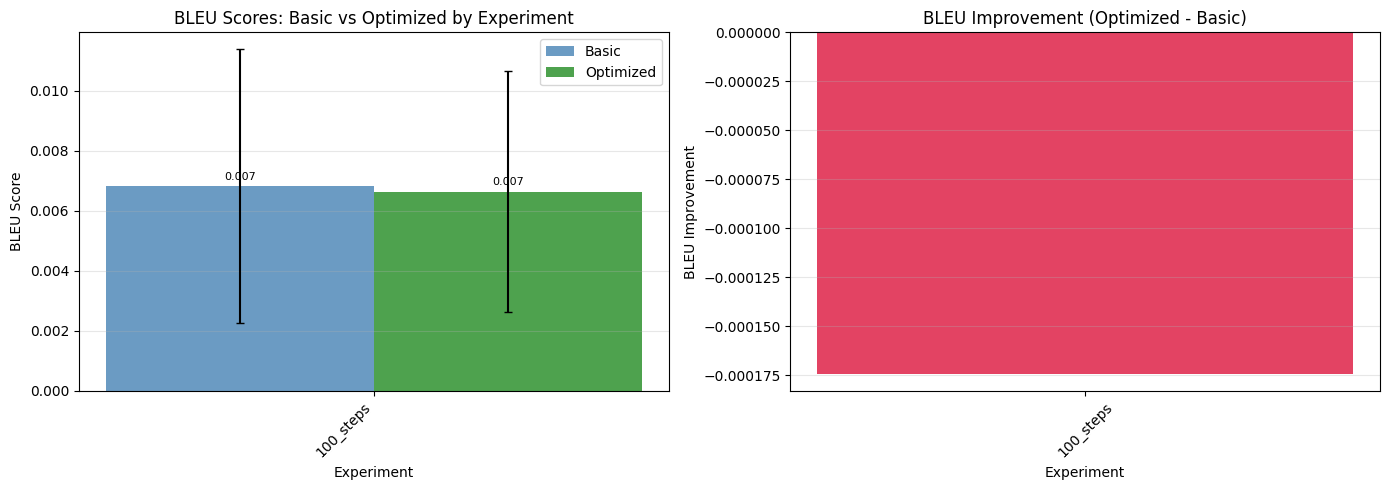

Saved BLEU comparison plot: /content/rlhf_experiments/bleu_comparison_20260429_101115.png


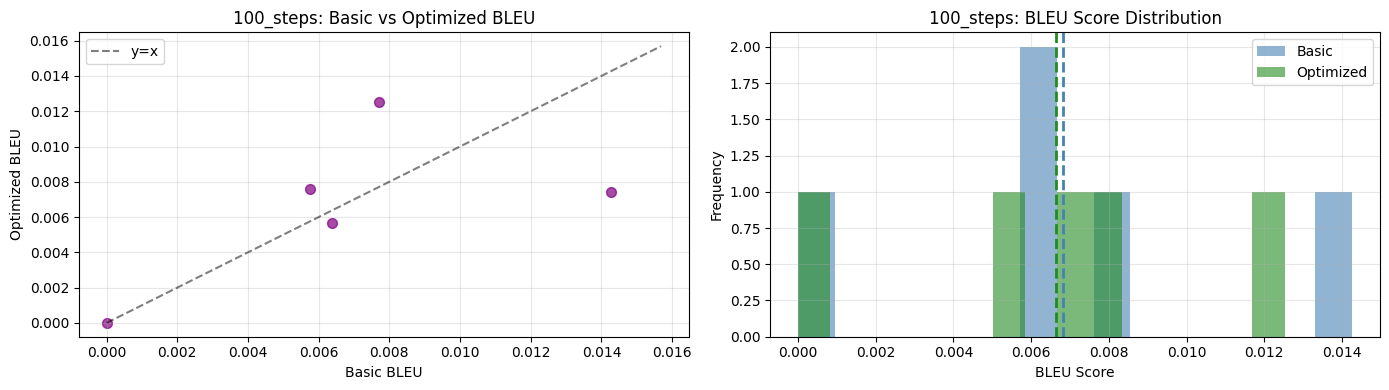

Saved BLEU detailed analysis: /content/rlhf_experiments/bleu_detailed_20260429_101115.png


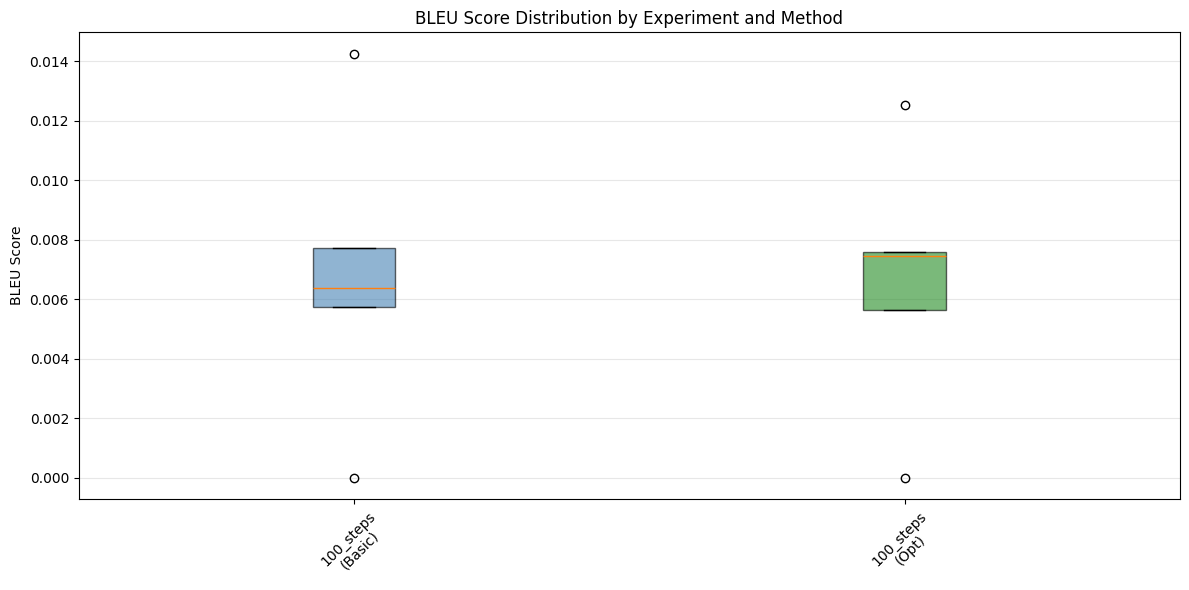

Saved BLEU boxplot: /content/rlhf_experiments/bleu_boxplot_20260429_101115.png

Generating COMET graphics...


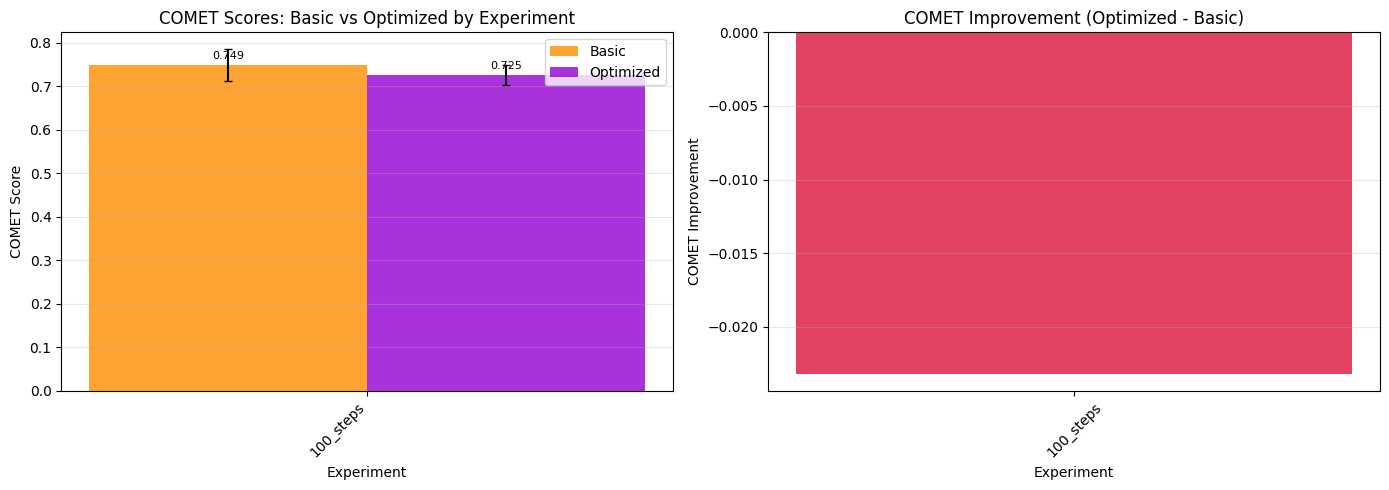

Saved COMET comparison plot: /content/rlhf_experiments/comet_comparison_20260429_101115.png


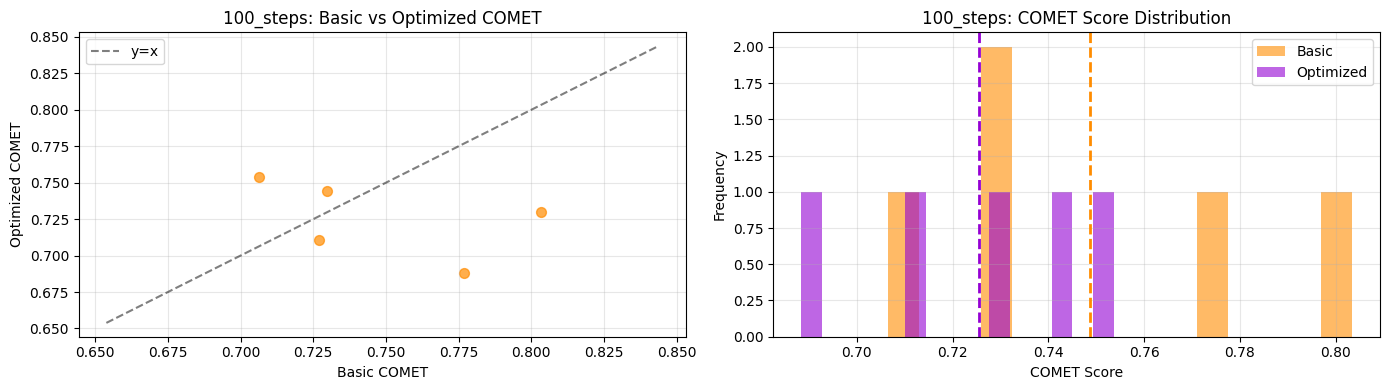

Saved COMET detailed analysis: /content/rlhf_experiments/comet_detailed_20260429_101115.png


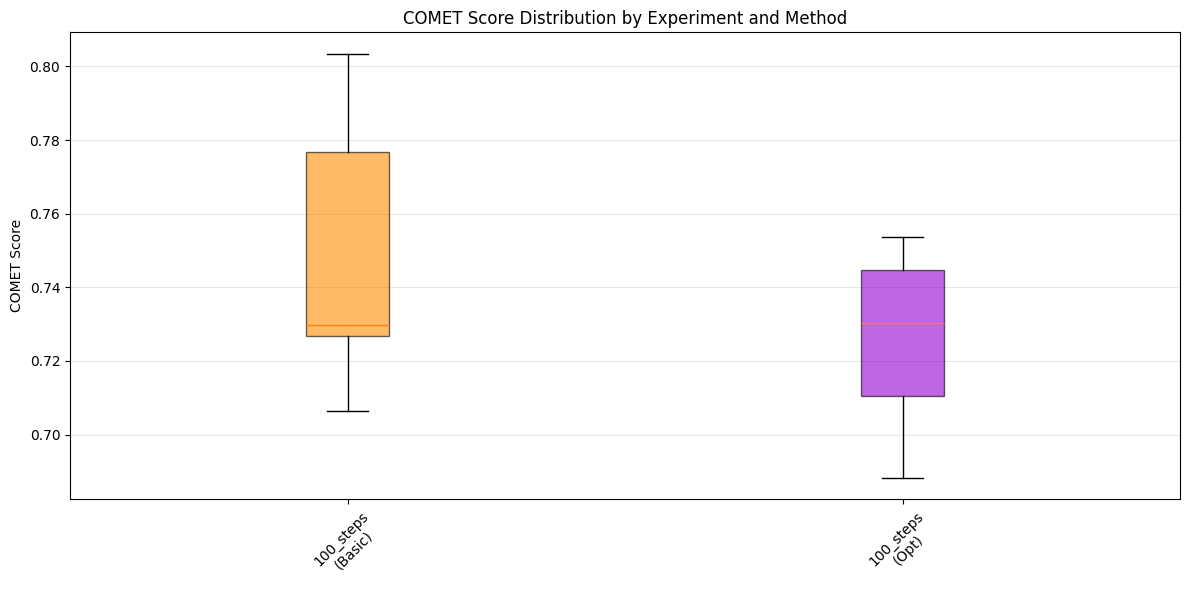

Saved COMET boxplot: /content/rlhf_experiments/comet_boxplot_20260429_101115.png


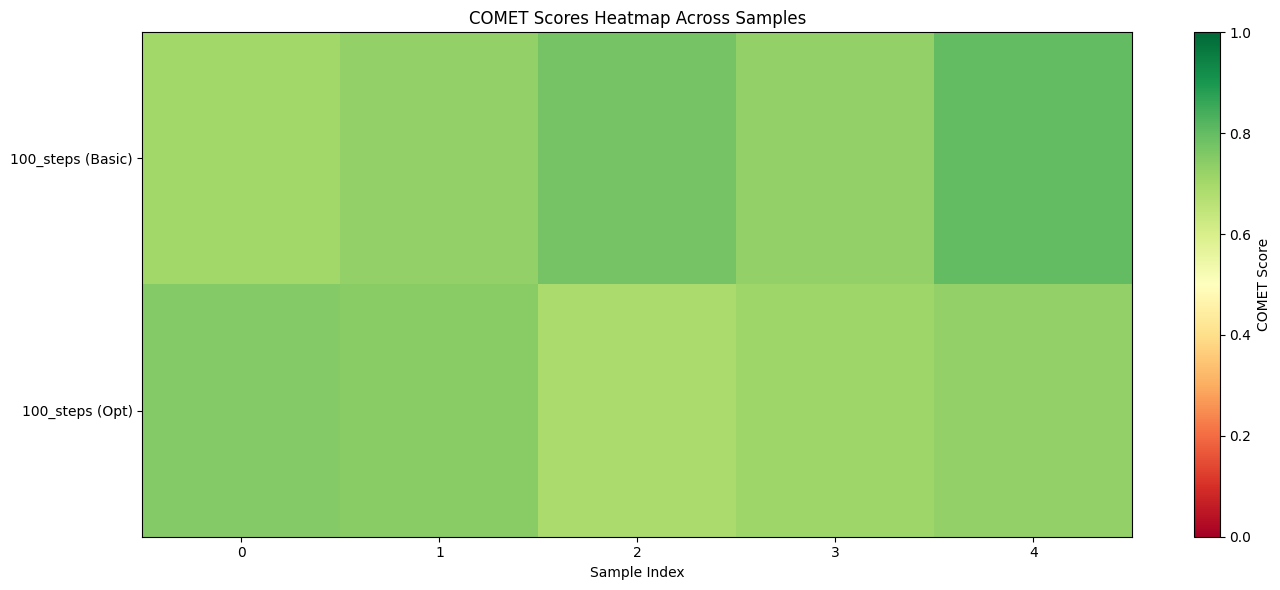

Saved COMET heatmap: /content/rlhf_experiments/comet_heatmap_20260429_101115.png

Generating combined analysis...


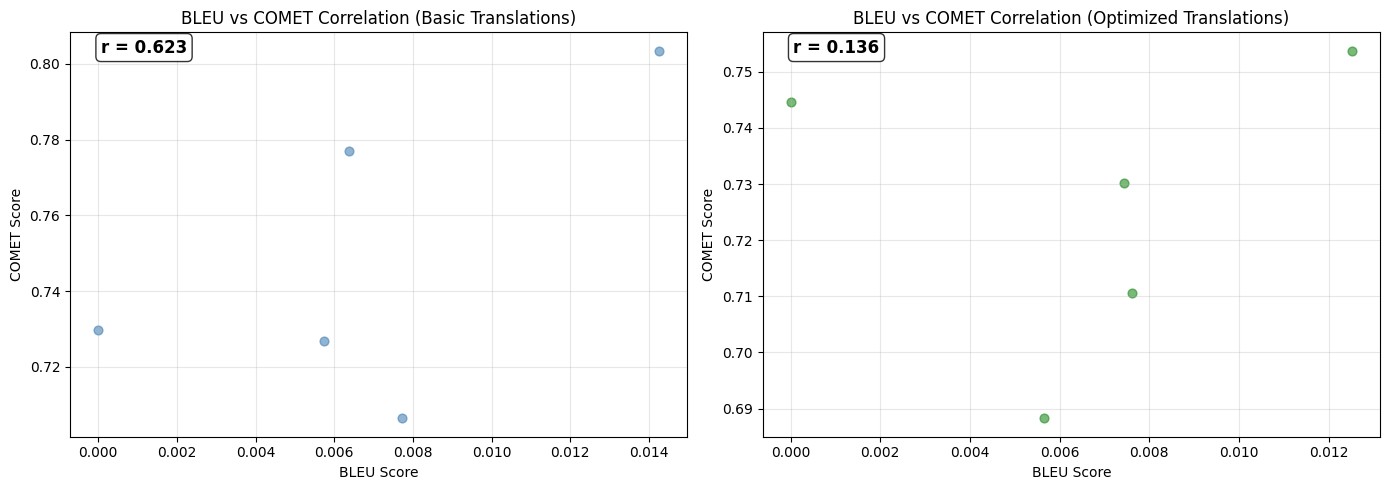

Saved BLEU-COMET correlation plot: /content/rlhf_experiments/bleu_comet_correlation_20260429_101116.png


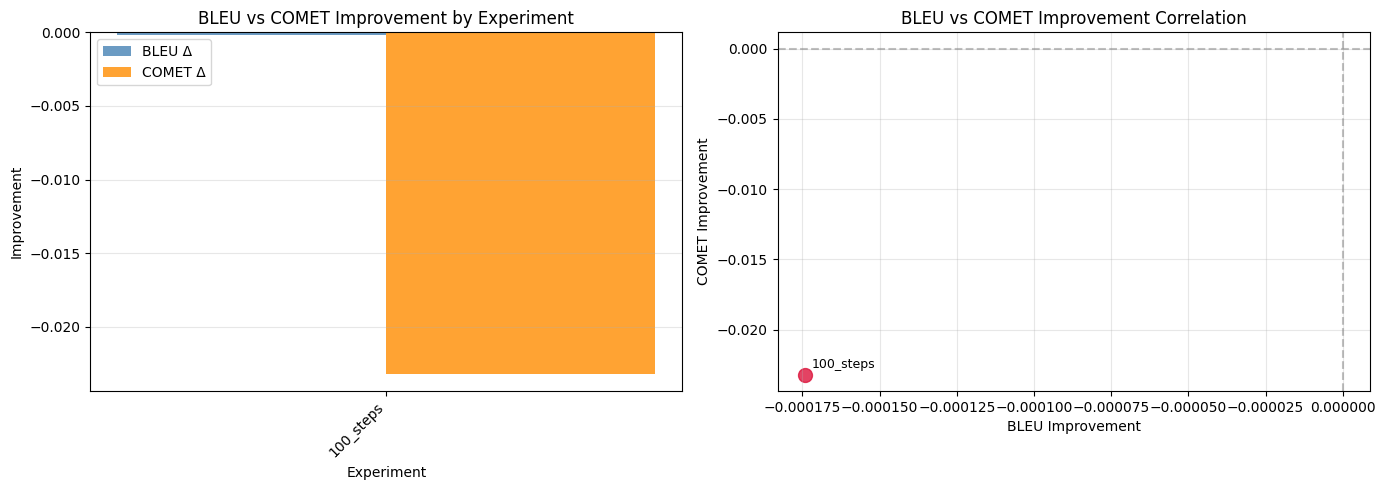

Saved improvement comparison plot: /content/rlhf_experiments/improvement_comparison_20260429_101116.png


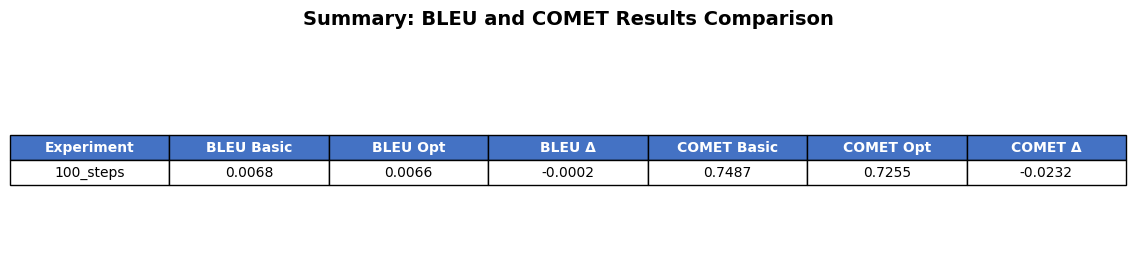

Saved summary table: /content/rlhf_experiments/summary_table_20260429_101116.png

Saved consolidated metrics: /content/rlhf_experiments/consolidated_metrics.json

ALL GRAPHICS AND RESULTS SAVED

Saved plots:
  - /content/rlhf_experiments/bleu_comparison_20260429_101115.png
  - /content/rlhf_experiments/bleu_detailed_20260429_101115.png
  - /content/rlhf_experiments/bleu_boxplot_20260429_101115.png
  - /content/rlhf_experiments/comet_comparison_20260429_101115.png
  - /content/rlhf_experiments/comet_detailed_20260429_101115.png
  - /content/rlhf_experiments/comet_boxplot_20260429_101115.png
  - /content/rlhf_experiments/comet_heatmap_20260429_101115.png
  - /content/rlhf_experiments/bleu_comet_correlation_20260429_101116.png
  - /content/rlhf_experiments/improvement_comparison_20260429_101116.png
  - /content/rlhf_experiments/summary_table_20260429_101116.png


In [29]:
# ============================================================================
# GENERATE ALL GRAPHICS
# ============================================================================

print('Generating BLEU graphics...')
bleu_plots = plot_bleu_results(all_bleu_results, EXPERIMENT_DIR)

print('\nGenerating COMET graphics...')
comet_plots = plot_comet_results(all_comet_results, EXPERIMENT_DIR)

print('\nGenerating combined analysis...')
combined_plots = plot_bleu_comet_correlation(all_bleu_results, all_comet_results, EXPERIMENT_DIR)

# Save consolidated metrics JSON
consolidated_metrics = {
    'bleu_results': {k: {'statistics': v['statistics']} for k, v in all_bleu_results.items()},
    'comet_results': {k: {'statistics': v['statistics']} for k, v in all_comet_results.items()},
}

metrics_path = os.path.join(EXPERIMENT_DIR, 'consolidated_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(consolidated_metrics, f, indent=2)
print(f'\nSaved consolidated metrics: {metrics_path}')

print(f'\n{"="*70}')
print('ALL GRAPHICS AND RESULTS SAVED')
print(f'{"="*70}')
print(f'\nSaved plots:')
for p in bleu_plots + comet_plots + combined_plots:
    print(f'  - {p}')

---
## Download Results

All experiment results are saved in `/content/rlhf_experiments/`.
You can download them using the file browser on the left, or run the cell below to create a zip file.

In [ ]:
# Create zip file of all results for easy download
import shutil

zip_path = '/content/rlhf_experiments_results'
shutil.make_archive(zip_path, 'zip', EXPERIMENT_DIR)
print(f'\nCreated zip file: {zip_path}.zip')
print('\nDownload this file to save all experiment results!')